# 企業導入 AI 開發工具的公開社群分析


## 摘要

本研究以 GitHub issues/comments 與 Hacker News comments 分析 AI 開發工具導入相關問題，觀察資料來源差異、文字訊號、情緒、主題、社會網絡與可追溯證據。


## 資料來源

資料皆來自公開 GitHub 與 Hacker News，並限定 2022-01-01 之後的公開資料

In [ ]:
# 匯入套件、設定資料路徑、抓取參數與視覺化環境。
from pathlib import Path
from itertools import combinations
from collections import Counter
import html
import json
import math
import os
import re
import subprocess
import time
import warnings

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from IPython.display import Markdown, display
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import normalize
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

DATA_DIR = Path("Data")
DATA_PATH = DATA_DIR / "github_ai_tool_issues.csv"
HN_DATA_PATH = DATA_DIR / "hackernews_ai_tool_comments.csv"
GITHUB_FETCH_STATE_PATH = DATA_DIR / "github_fetch_state.json"
HN_FETCH_STATE_PATH = DATA_DIR / "hackernews_fetch_state.json"
BERT_EMBEDDING_PATH = DATA_DIR / "bert_embeddings_all_minilm_l6_v2.npy"
QDRANT_PATH = DATA_DIR / "qdrant_ai_tool_vectors"
QDRANT_COLLECTION = "ai_tool_discussions"
BERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
FORCE_REFRESH_DATA = False
REPORT_SNAPSHOT_MODE = True
FETCH_MORE_DATA = False
FORCE_REFRESH_BERT_EMBEDDINGS = False
FORCE_REBUILD_QDRANT = False
USE_OLLAMA_SUMMARY = False
OLLAMA_MODEL = "llama3.2:3b"
TARGET_TOTAL_DOCUMENTS = 20000
ANALYSIS_START_DATE = "2022-01-01"
ANALYSIS_END_DATE = None
APPEND_EXISTING_DATA = True
USE_FETCH_STATE = True
RESET_FETCH_STATE = False
WAIT_ON_GITHUB_RATE_LIMIT = False
MAX_GITHUB_RATE_LIMIT_WAIT_SECONDS = 3700
GITHUB_REQUEST_DELAY_SECONDS = 0.05
MAX_FETCH_SECONDS_PER_SOURCE = 900
MAX_NEW_GITHUB_DOCUMENTS_PER_RUN = 3000
MAX_GITHUB_COMMENT_REQUESTS_PER_RUN = 350
MAX_NEW_HN_DOCUMENTS_PER_RUN = 2500
FETCH_EVENTS = []

REPOS = [
    "microsoft/vscode-copilot-release",
    "openai/openai-python",
    "langchain-ai/langchain",
    "run-llama/llama_index",
    "ollama/ollama",
    "continuedev/continue",
    "microsoft/autogen",
    "crewAIInc/crewAI",
    "Significant-Gravitas/AutoGPT",
    "huggingface/transformers",
    "huggingface/text-generation-inference",
    "deepset-ai/haystack",
    "langgenius/dify",
    "open-webui/open-webui",
    "FlowiseAI/Flowise",
    "qdrant/qdrant",
    "qdrant/qdrant-client",
    "milvus-io/pymilvus",
    "anthropics/anthropic-sdk-python",
    "browser-use/browser-use",
]

GITHUB_ISSUE_PAGES_PER_REPO = 8
GITHUB_ISSUES_PER_PAGE = 100
MAX_COMMENTS_PER_ISSUE = 25

HN_QUERIES = [
    "GitHub Copilot",
    "ChatGPT coding",
    "AI coding assistant",
    "OpenAI API",
    "code generation",
    "LLM application",
    "LangChain",
    "LlamaIndex",
    "Ollama",
    "local LLM",
    "AI agent",
    "RAG",
    "vector database",
    "prompt injection",
    "data privacy AI coding",
]
MAX_HN_PAGES_PER_QUERY = 6
MAX_HN_HITS_PER_PAGE = 100

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5.8)
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Noto Sans CJK TC",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans",
]


In [ ]:
# 定義公開資料抓取、CSV 讀寫、欄位標準化與合併流程。
def read_fetch_state(path):
    if not USE_FETCH_STATE or RESET_FETCH_STATE or FORCE_REFRESH_DATA or not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception:
        return {}


def write_fetch_state(path, state):
    if not USE_FETCH_STATE:
        return
    DATA_DIR.mkdir(exist_ok=True)
    path.write_text(json.dumps(state, ensure_ascii=False, indent=2), encoding="utf-8")


def github_rate_limit_message(response):
    try:
        message = response.json().get("message", "")
    except Exception:
        message = response.text[:200]
    reset_epoch = response.headers.get("X-RateLimit-Reset")
    reset_at = ""
    wait_seconds = None
    if reset_epoch:
        try:
            wait_seconds = max(0, int(reset_epoch) - int(time.time()) + 5)
            reset_at = pd.to_datetime(int(reset_epoch), unit="s", utc=True).isoformat()
        except Exception:
            wait_seconds = None
    return message, reset_at, wait_seconds


def github_get(url, params=None):
    headers = {
        "Accept": "application/vnd.github+json",
        "User-Agent": "ai-dev-tools-social-analysis",
    }
    token = os.environ.get("GITHUB_TOKEN")
    if token:
        headers["Authorization"] = f"Bearer {token}"
    response = requests.get(url, headers=headers, params=params, timeout=40)
    if response.status_code in {403, 429}:
        message, reset_at, wait_seconds = github_rate_limit_message(response)
        is_rate_limited = (
            response.headers.get("X-RateLimit-Remaining") == "0"
            or "rate limit" in message.lower()
            or "secondary rate" in message.lower()
        )
        if is_rate_limited:
            if WAIT_ON_GITHUB_RATE_LIMIT and wait_seconds is not None and wait_seconds <= MAX_GITHUB_RATE_LIMIT_WAIT_SECONDS:
                time.sleep(wait_seconds)
                response = requests.get(url, headers=headers, params=params, timeout=40)
            else:
                raise RuntimeError(f"github_rate_limit reset_at={reset_at or 'unknown'} message={message[:120]}")
    response.raise_for_status()
    return response.json()


def compact_labels(labels):
    if not isinstance(labels, list):
        return ""
    return ", ".join(label.get("name", "") for label in labels if label.get("name"))


def fetch_github_documents():
    rows = []
    state = read_fetch_state(GITHUB_FETCH_STATE_PATH)
    stop_collection = False
    started_at = time.time()
    comment_requests = 0

    def should_stop():
        if len(rows) >= MAX_NEW_GITHUB_DOCUMENTS_PER_RUN:
            FETCH_EVENTS.append({"source": "GitHub", "repo": "all", "page": "", "event": "max_new_github_documents_per_run_reached"})
            return True
        if time.time() - started_at >= MAX_FETCH_SECONDS_PER_SOURCE:
            FETCH_EVENTS.append({"source": "GitHub", "repo": "all", "page": "", "event": "max_fetch_seconds_per_source_reached"})
            return True
        return False

    for repo in REPOS:
        if stop_collection or should_stop():
            break
        owner_repo = repo.strip("/")
        issues_url = f"https://api.github.com/repos/{owner_repo}/issues"
        start_page = int(state.get(owner_repo, 1)) if USE_FETCH_STATE and not FORCE_REFRESH_DATA else 1
        end_page = start_page + GITHUB_ISSUE_PAGES_PER_REPO
        print(f"[GitHub] {owner_repo}: pages {start_page}-{end_page - 1}", flush=True)

        for page in range(start_page, end_page):
            if should_stop():
                stop_collection = True
                break
            try:
                page_issues = github_get(
                    issues_url,
                    params={
                        "state": "all",
                        "sort": "updated",
                        "direction": "desc",
                        "per_page": GITHUB_ISSUES_PER_PAGE,
                        "page": page,
                    },
                )
            except Exception as exc:
                FETCH_EVENTS.append({"source": "GitHub", "repo": owner_repo, "page": page, "event": str(exc)[:240]})
                stop_collection = "github_rate_limit" in str(exc)
                break

            if not page_issues:
                state[owner_repo] = page
                write_fetch_state(GITHUB_FETCH_STATE_PATH, state)
                break

            for issue in page_issues:
                if should_stop():
                    stop_collection = True
                    break
                if "pull_request" in issue:
                    continue

                issue_author = (issue.get("user") or {}).get("login", "")
                title = issue.get("title") or ""
                body = issue.get("body") or ""
                labels = compact_labels(issue.get("labels", []))
                issue_number = issue.get("number")

                rows.append(
                    {
                        "repo": owner_repo,
                        "issue_number": issue_number,
                        "source_type": "issue",
                        "title": title,
                        "body": body,
                        "text": f"{title}\n{body}".strip(),
                        "user": issue_author,
                        "issue_author": issue_author,
                        "created_at": issue.get("created_at"),
                        "updated_at": issue.get("updated_at"),
                        "state": issue.get("state"),
                        "labels": labels,
                        "url": issue.get("html_url"),
                        "comments_count": issue.get("comments", 0),
                        "source_platform": "GitHub",
                        "document_id": f"github:{owner_repo}:issue:{issue_number}",
                        "parent_id": "",
                        "thread_id": f"github:{owner_repo}:issue:{issue_number}",
                    }
                )

                if (
                    issue.get("comments", 0) > 0
                    and issue.get("comments_url")
                    and comment_requests < MAX_GITHUB_COMMENT_REQUESTS_PER_RUN
                ):
                    try:
                        comments = github_get(
                            issue["comments_url"],
                            params={"per_page": MAX_COMMENTS_PER_ISSUE},
                        )
                        comment_requests += 1
                        time.sleep(GITHUB_REQUEST_DELAY_SECONDS)
                    except Exception as exc:
                        comments = []
                        if "github_rate_limit" in str(exc):
                            FETCH_EVENTS.append({"source": "GitHub", "repo": owner_repo, "page": page, "event": str(exc)[:240]})
                            stop_collection = True

                    for comment in comments[:MAX_COMMENTS_PER_ISSUE]:
                        if should_stop():
                            stop_collection = True
                            break
                        comment_user = (comment.get("user") or {}).get("login", "")
                        comment_body = comment.get("body") or ""
                        comment_id = comment.get("id") or comment.get("html_url") or len(rows)
                        rows.append(
                            {
                                "repo": owner_repo,
                                "issue_number": issue_number,
                                "source_type": "comment",
                                "title": title,
                                "body": comment_body,
                                "text": comment_body,
                                "user": comment_user,
                                "issue_author": issue_author,
                                "created_at": comment.get("created_at"),
                                "updated_at": comment.get("updated_at"),
                                "state": issue.get("state"),
                                "labels": labels,
                                "url": comment.get("html_url"),
                                "comments_count": issue.get("comments", 0),
                                "source_platform": "GitHub",
                                "document_id": f"github:{owner_repo}:issue:{issue_number}:comment:{comment_id}",
                                "parent_id": f"github:{owner_repo}:issue:{issue_number}",
                                "thread_id": f"github:{owner_repo}:issue:{issue_number}",
                            }
                        )

            state[owner_repo] = page + 1
            write_fetch_state(GITHUB_FETCH_STATE_PATH, state)
            print(f"[GitHub] {owner_repo} page {page} done, new rows={len(rows):,}, comment requests={comment_requests}", flush=True)
            time.sleep(GITHUB_REQUEST_DELAY_SECONDS)

    return pd.DataFrame(rows)

def strip_html(value):
    text = html.unescape(str(value or ""))
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def fetch_hackernews_comments():
    rows = []
    endpoint = "https://hn.algolia.com/api/v1/search_by_date"
    state = read_fetch_state(HN_FETCH_STATE_PATH)
    started_at = time.time()

    for query in HN_QUERIES:
        if len(rows) >= MAX_NEW_HN_DOCUMENTS_PER_RUN:
            FETCH_EVENTS.append({"source": "Hacker News", "repo": query, "page": "", "event": "max_new_hn_documents_per_run_reached"})
            break
        if time.time() - started_at >= MAX_FETCH_SECONDS_PER_SOURCE:
            FETCH_EVENTS.append({"source": "Hacker News", "repo": query, "page": "", "event": "max_fetch_seconds_per_source_reached"})
            break

        start_page = int(state.get(query, 0)) if USE_FETCH_STATE and not FORCE_REFRESH_DATA else 0
        end_page = start_page + MAX_HN_PAGES_PER_QUERY
        print(f"[Hacker News] {query}: pages {start_page}-{end_page - 1}", flush=True)

        for page in range(start_page, end_page):
            if len(rows) >= MAX_NEW_HN_DOCUMENTS_PER_RUN or time.time() - started_at >= MAX_FETCH_SECONDS_PER_SOURCE:
                break
            try:
                response = requests.get(
                    endpoint,
                    params={
                        "query": query,
                        "tags": "comment",
                        "hitsPerPage": MAX_HN_HITS_PER_PAGE,
                        "page": page,
                    },
                    timeout=40,
                )
                response.raise_for_status()
                page_hits = response.json().get("hits", [])
            except Exception as exc:
                FETCH_EVENTS.append({"source": "Hacker News", "repo": query, "page": page, "event": str(exc)[:240]})
                page_hits = []
            if not page_hits:
                break
            for hit in page_hits:
                body = strip_html(hit.get("comment_text"))
                if not body:
                    continue
                object_id = str(hit.get("objectID") or "")
                story_id = str(hit.get("story_id") or "")
                story_title = hit.get("story_title") or query
                rows.append(
                    {
                        "source_platform": "Hacker News",
                        "repo": f"Hacker News / {query}",
                        "issue_number": story_id or object_id,
                        "source_type": "comment",
                        "title": story_title,
                        "body": body,
                        "text": f"{story_title}\n{body}".strip(),
                        "user": hit.get("author") or "",
                        "issue_author": str(hit.get("parent_id") or story_id or ""),
                        "document_id": f"hn:{object_id}" if object_id else f"hn:{query}:{page}:{len(rows)}",
                        "parent_id": str(hit.get("parent_id") or ""),
                        "thread_id": story_id,
                        "created_at": hit.get("created_at"),
                        "updated_at": hit.get("created_at"),
                        "state": "public",
                        "labels": query,
                        "url": f"https://news.ycombinator.com/item?id={object_id}" if object_id else "",
                        "comments_count": np.nan,
                    }
                )
            state[query] = page + 1
            write_fetch_state(HN_FETCH_STATE_PATH, state)
            print(f"[Hacker News] {query} page {page} done, new rows={len(rows):,}", flush=True)
    return pd.DataFrame(rows)


REQUIRED_COLUMNS = {
    "repo",
    "issue_number",
    "source_type",
    "title",
    "body",
    "text",
    "user",
    "issue_author",
    "created_at",
    "updated_at",
    "state",
    "labels",
    "url",
    "source_platform",
    "document_id",
    "parent_id",
    "thread_id",
}


def cache_is_valid(path, required_columns=REQUIRED_COLUMNS):
    if not path.exists():
        return False, "file_missing"
    try:
        cached = pd.read_csv(path, nrows=5)
    except Exception as exc:
        return False, f"read_error: {exc}"
    missing = sorted(required_columns - set(cached.columns))
    if missing:
        return False, f"missing_columns: {missing}"
    if cached.empty:
        return False, "empty_file"
    return True, "valid"


def standardize_documents(frame, platform):
    df_out = frame.copy()
    df_out["source_platform"] = df_out.get("source_platform", platform)
    df_out["source_platform"] = df_out["source_platform"].fillna(platform)
    for column in REQUIRED_COLUMNS:
        if column not in df_out.columns:
            df_out[column] = ""
        df_out[column] = df_out[column].fillna("").astype(str)
    if platform == "GitHub":
        issue_mask = df_out["source_type"].astype(str).eq("issue")
        comment_mask = df_out["source_type"].astype(str).eq("comment")
        df_out.loc[issue_mask, "document_id"] = (
            "github:"
            + df_out.loc[issue_mask, "repo"].astype(str)
            + ":issue:"
            + df_out.loc[issue_mask, "issue_number"].astype(str)
        )
        comment_ids = df_out.loc[comment_mask, "url"].astype(str).str.extract(r"issuecomment-(\d+)", expand=False)
        comment_has_id = comment_mask.copy()
        comment_has_id.loc[comment_mask] = comment_ids.fillna("").str.strip().ne("").to_numpy()
        df_out.loc[comment_has_id, "document_id"] = (
            "github:"
            + df_out.loc[comment_has_id, "repo"].astype(str)
            + ":issue:"
            + df_out.loc[comment_has_id, "issue_number"].astype(str)
            + ":comment:"
            + df_out.loc[comment_has_id, "url"].astype(str).str.extract(r"issuecomment-(\d+)", expand=False).fillna("")
        )
        comment_no_id = comment_mask & ~comment_has_id
        df_out.loc[comment_no_id, "document_id"] = (
            "github:"
            + df_out.loc[comment_no_id, "repo"].astype(str)
            + ":issue:"
            + df_out.loc[comment_no_id, "issue_number"].astype(str)
            + ":comment_url:"
            + df_out.loc[comment_no_id, "url"].astype(str)
        )
        missing_doc = df_out["document_id"].astype(str).str.strip().eq("")
        df_out.loc[missing_doc, "document_id"] = (
            df_out.loc[missing_doc, "repo"].astype(str)
            + "#"
            + df_out.loc[missing_doc, "issue_number"].astype(str)
            + ":"
            + df_out.loc[missing_doc, "source_type"].astype(str)
            + ":"
            + df_out.loc[missing_doc].index.astype(str)
        )
        missing_thread = df_out["thread_id"].astype(str).str.strip().eq("")
        df_out.loc[missing_thread, "thread_id"] = (
            df_out.loc[missing_thread, "repo"].astype(str)
            + "#"
            + df_out.loc[missing_thread, "issue_number"].astype(str)
        )
    if platform == "Hacker News":
        hn_mask = df_out["source_platform"].astype(str).eq("Hacker News")
        doc_not_blank = df_out["document_id"].astype(str).str.strip().ne("")
        non_prefixed = hn_mask & doc_not_blank & ~df_out["document_id"].astype(str).str.startswith("hn:")
        df_out.loc[non_prefixed, "document_id"] = "hn:" + df_out.loc[non_prefixed, "document_id"].astype(str)
    missing_doc = df_out["document_id"].astype(str).str.strip().eq("")
    if missing_doc.any():
        df_out.loc[missing_doc, "document_id"] = (
            df_out.loc[missing_doc, "source_platform"].astype(str)
            + ":"
            + df_out.loc[missing_doc, "url"].astype(str)
            + ":"
            + df_out.loc[missing_doc, "repo"].astype(str)
            + ":"
            + df_out.loc[missing_doc, "issue_number"].astype(str)
            + ":"
            + df_out.loc[missing_doc, "source_type"].astype(str)
            + ":"
            + df_out.loc[missing_doc].index.astype(str)
        )
    return df_out


def deduplicate_documents(frame):
    if frame.empty:
        return frame
    df_out = frame.copy()
    df_out["document_id"] = df_out["document_id"].fillna("").astype(str)
    df_out["text"] = df_out["text"].fillna("").astype(str)
    df_out = df_out[df_out["document_id"].str.strip().ne("")]
    df_out = df_out[df_out["text"].str.strip().ne("")]
    df_out["_updated_sort"] = pd.to_datetime(df_out["updated_at"], errors="coerce", utc=True)
    df_out = (
        df_out.sort_values("_updated_sort", na_position="first")
        .drop_duplicates(subset=["document_id"], keep="last")
        .drop(columns=["_updated_sort"])
        .reset_index(drop=True)
    )
    return df_out


def load_or_fetch_dataset(path, fetcher, platform, force_refresh=False, fetch_more=False):
    valid, reason = cache_is_valid(path)
    existing = None
    if valid:
        existing = standardize_documents(pd.read_csv(path), platform)
        existing = deduplicate_documents(existing)
        if fetch_more and not force_refresh and TARGET_TOTAL_DOCUMENTS and len(existing) >= TARGET_TOTAL_DOCUMENTS:
            return existing, "target_reached_loaded_existing_csv", reason

    if force_refresh or fetch_more or not valid:
        DATA_DIR.mkdir(exist_ok=True)
        try:
            frame = fetcher()
            frame = standardize_documents(frame, platform)
            if frame.empty:
                raise ValueError("fetched_empty_dataframe")
            if existing is not None and APPEND_EXISTING_DATA and fetch_more and not force_refresh:
                frame = pd.concat([existing, frame], ignore_index=True, sort=False)
            frame = deduplicate_documents(frame)
            frame.to_csv(path, index=False, encoding="utf-8-sig")
            if force_refresh:
                status = "refetched_forced_rebuilt_csv"
            elif fetch_more:
                status = "fetched_more_appended_deduplicated_csv"
            else:
                status = f"refetched_{reason}"
        except Exception as exc:
            if existing is not None:
                frame = existing
                status = f"fetch_failed_used_existing_csv: {type(exc).__name__}: {str(exc)[:120]}"
            else:
                frame = pd.DataFrame(columns=sorted(REQUIRED_COLUMNS))
                status = f"fetch_failed_no_valid_csv: {type(exc).__name__}: {str(exc)[:120]}"
    else:
        frame = existing
        status = "loaded_existing_csv"
    return frame, status, reason


github_df, github_status, github_cache_check = load_or_fetch_dataset(
    DATA_PATH,
    fetch_github_documents,
    "GitHub",
    FORCE_REFRESH_DATA,
    FETCH_MORE_DATA,
)
hn_df, hn_status, hn_cache_check = load_or_fetch_dataset(
    HN_DATA_PATH,
    fetch_hackernews_comments,
    "Hacker News",
    FORCE_REFRESH_DATA,
    FETCH_MORE_DATA,
)

cache_status = pd.DataFrame(
    [
        {"dataset": "GitHub issues/comments", "path": str(DATA_PATH), "local_csv_check": github_cache_check, "load_status": github_status, "documents": len(github_df)},
        {"dataset": "Hacker News comments", "path": str(HN_DATA_PATH), "local_csv_check": hn_cache_check, "load_status": hn_status, "documents": len(hn_df)},
    ]
)

raw_df = pd.concat([github_df, hn_df], ignore_index=True, sort=False)
display(Markdown(f"資料抓取參數：`FORCE_REFRESH_DATA = {FORCE_REFRESH_DATA}`、`FETCH_MORE_DATA = {FETCH_MORE_DATA}`、`TARGET_TOTAL_DOCUMENTS = {TARGET_TOTAL_DOCUMENTS:,}`。資料蒐集以公開 API 分批進行，並以 `document_id` 去重後寫入本機 CSV。"))
display(cache_status)
if FETCH_EVENTS:
    display(pd.DataFrame(FETCH_EVENTS).tail(10))
display(Markdown(
    "本研究抓取後的資料會固定存成 CSV 到 `Data` 資料夾："
    f"`{DATA_PATH.as_posix()}` 與 `{HN_DATA_PATH.as_posix()}`。"
    "後續所有分析均讀取這兩份 CSV 合併後的資料，確保結果可重現。"
    f"目前每次執行的 GitHub 抓取上限為每個 repo 最多 {GITHUB_ISSUE_PAGES_PER_REPO * GITHUB_ISSUES_PER_PAGE} 筆 issue、"
    f"每個 issue 最多 {MAX_COMMENTS_PER_ISSUE} 筆 comment；"
    f"Hacker News 每個查詢詞每次最多 {MAX_HN_PAGES_PER_QUERY * MAX_HN_HITS_PER_PAGE} 筆留言。"
))

date_columns = ["created_at", "updated_at"]
for col in date_columns:
    raw_df[col] = pd.to_datetime(raw_df[col], errors="coerce", utc=True)

analysis_start = pd.Timestamp(ANALYSIS_START_DATE, tz="UTC") if ANALYSIS_START_DATE else None
analysis_end = pd.Timestamp(ANALYSIS_END_DATE, tz="UTC") if ANALYSIS_END_DATE else None
before_period_filter_count = len(raw_df)
if analysis_start is not None:
    raw_df = raw_df[raw_df["created_at"].ge(analysis_start)].copy()
if analysis_end is not None:
    raw_df = raw_df[raw_df["created_at"].le(analysis_end)].copy()
period_filtered_count = before_period_filter_count - len(raw_df)

raw_df["source_platform"] = raw_df["source_platform"].fillna("GitHub")
raw_df = raw_df.dropna(subset=["repo", "text", "user"]).copy()
raw_df["text"] = raw_df["text"].fillna("").astype(str)
raw_df = raw_df[raw_df["text"].str.strip().ne("")]
raw_df = raw_df.reset_index(drop=True)

display(Markdown(f"研究期間：**{ANALYSIS_START_DATE or '不限'}** 至 **{ANALYSIS_END_DATE or '資料最新日期'}**；期間外排除 **{period_filtered_count:,}** 筆公開文件。"))

display(Markdown(f"本研究共取得 **{len(raw_df):,}** 筆公開文件，涵蓋 **{raw_df['source_platform'].nunique()}** 種公開平台、**{raw_df['repo'].nunique()}** 個資料子來源與 **{raw_df['user'].nunique()}** 位公開帳號。"))
display(raw_df[["source_platform", "repo", "source_type", "issue_number", "user", "state", "created_at", "title"]].head(8))


,dataset,path,local_csv_check,load_status,documents
0,GitHub issues/comments,Data\github_ai_tool_issues.csv,valid,loaded_existing_csv,9709
1,Hacker News comments,Data\hackernews_ai_tool_comments.csv,valid,loaded_existing_csv,5173


,source_platform,repo,source_type,issue_number,user,state,created_at,title
0,GitHub,openai/openai-python,issue,65,not4fame,closed,2022-01-18 07:42:06+00:00,Can't send files - missing purpose
1,GitHub,openai/openai-python,issue,70,zzj0402,closed,2022-01-31 04:57:32+00:00,openai: error: invalid choice: 'tools' (choose...
2,GitHub,openai/openai-python,issue,73,rnag,closed,2022-02-14 15:46:32+00:00,Unable to use custom certs with OpenAI client
3,GitHub,openai/openai-python,issue,89,Travis-Barton,closed,2022-04-20 19:04:46+00:00,Calculating tokens prior to prompt
4,GitHub,openai/openai-python,issue,95,andrewchernyh,closed,2022-05-19 09:45:44+00:00,HTTP Connection is not reused in stream mode
5,GitHub,openai/openai-python,issue,96,tsoe200012,closed,2022-05-21 16:44:31+00:00,openaipython
6,GitHub,openai/openai-python,issue,100,henmaster,closed,2022-06-14 22:28:41+00:00,Error when installing on kali-linux
7,GitHub,microsoft/vscode-copilot-release,comment,521,digitarald,open,2023-10-31 17:54:38+00:00,VSCode: Can i not uninstall Copilot Chat witho...


In [ ]:
# 彙整資料來源、文件數、時間範圍與基本資料結構。
repo_summary = (
    raw_df.groupby(["source_platform", "source_type"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .sort_values("total", ascending=False)
)

source_detail_summary = (
    raw_df.groupby(["source_platform", "repo"])
    .size()
    .reset_index(name="documents")
    .sort_values(["source_platform", "documents"], ascending=[True, False])
)

time_span = pd.DataFrame(
    {
        "項目": ["最早資料時間", "最新資料時間", "文件總數", "公開平台數", "資料子來源數", "使用者數"],
        "數值": [
            raw_df["created_at"].min(),
            raw_df["created_at"].max(),
            len(raw_df),
            raw_df["source_platform"].nunique(),
            raw_df["repo"].nunique(),
            raw_df["user"].nunique(),
        ],
    }
)

display(time_span)
display(repo_summary)
display(source_detail_summary.head(12))


,項目,數值
0,最早資料時間,2022-01-07 23:25:10+00:00
1,最新資料時間,2026-05-31 13:43:00+00:00
2,文件總數,14843
3,公開平台數,2
4,資料子來源數,19
5,使用者數,9812


source_type,comment,issue,total
source_platform,,,
GitHub,2548,7146,9694
Hacker News,5149,0,5149


,source_platform,repo,documents
3,GitHub,microsoft/vscode-copilot-release,5096
4,GitHub,ollama/ollama,1522
6,GitHub,run-llama/llama_index,1206
1,GitHub,langchain-ai/langchain,952
0,GitHub,continuedev/continue,819
2,GitHub,microsoft/autogen,83
5,GitHub,openai/openai-python,16
18,Hacker News,Hacker News / vector database,998
16,Hacker News,Hacker News / local LLM,987
13,Hacker News,Hacker News / RAG,973


## 資料分析流程

從資料讀取、清理、文字探勘、情緒分析、主題分類、embedding、Qdrant 與 Graph RAG 證據整理依序執行。


### 文字探勘

這段產生詞頻、TF-IDF、N-gram、關聯規則、情緒分布與主題分群結果。


In [ ]:
# 建立文字清理規則，產生乾淨文字與文件長度欄位。
STOP_WORDS = {
    "the", "and", "for", "that", "this", "with", "from", "have", "has", "had",
    "you", "your", "are", "was", "were", "but", "not", "can", "cannot", "could",
    "would", "should", "will", "just", "when", "what", "where", "which", "who",
    "how", "why", "all", "any", "our", "out", "get", "got", "use", "using",
    "used", "also", "into", "than", "then", "there", "here", "been", "being",
    "same", "more", "most", "some", "such", "only", "very", "much", "many",
    "please", "thanks", "thank", "hello", "hi", "com", "https", "http",
    "github", "copilot", "openai", "langchain", "vscode", "python",
}

TOKEN_PATTERN = r"(?u)\b[a-zA-Z][a-zA-Z0-9_\-\.]{2,}\b"


def clean_text(value):
    text = str(value)
    text = re.sub(r"```.*?```", " ", text, flags=re.S)
    text = re.sub(r"`[^`]*`", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@[A-Za-z0-9_\-]+", " ", text)
    text = re.sub(r"#[A-Za-z0-9_\-]+", " ", text)
    text = re.sub(r"[^A-Za-z0-9_\-\.\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def make_excerpt(text, max_len=180):
    value = re.sub(r"\s+", " ", str(text)).strip()
    return value[:max_len] + ("..." if len(value) > max_len else "")


df = raw_df.copy()
df["clean_text"] = df["text"].map(clean_text)
df["word_count"] = df["clean_text"].str.split().map(len)
df = df[df["word_count"] >= 3].reset_index(drop=True)

display(Markdown(f"清理後保留 **{len(df):,}** 筆文字文件，平均字詞數為 **{df['word_count'].mean():.1f}**。"))
display(df[["repo", "source_type", "user", "word_count", "clean_text"]].head(6))


,repo,source_type,user,word_count,clean_text
0,openai/openai-python,issue,not4fame,41,can t send files - missing purpose hi i am try...
1,openai/openai-python,issue,zzj0402,11,openai error invalid choice tools choose from ...
2,openai/openai-python,issue,rnag,113,unable to use custom certs with openai client ...
3,openai/openai-python,issue,Travis-Barton,75,calculating tokens prior to prompt hey all i m...
4,openai/openai-python,issue,andrewchernyh,49,http connection is not reused in stream mode r...
5,openai/openai-python,issue,henmaster,42,error when installing on kali-linux for some r...


,term,count
0,version,21313
1,enabled,14986
2,info,14621
3,code,11353
4,issue,9990
5,available,9875
6,installed,9676
7,details,9260
8,summary,9008
9,model,7343


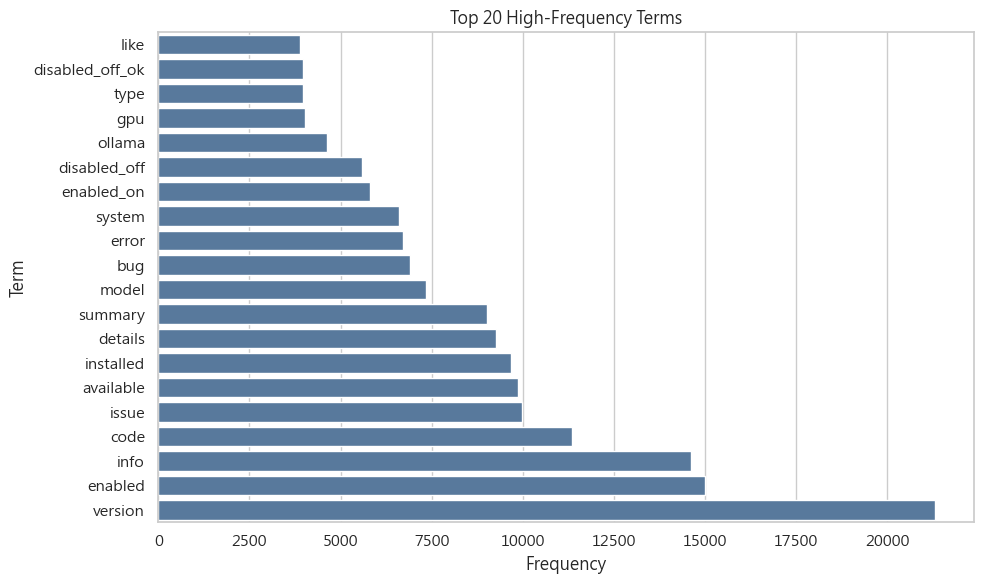

In [ ]:
# 計算高頻詞並繪製詞頻圖，初步觀察討論焦點。
count_vectorizer = CountVectorizer(
    token_pattern=TOKEN_PATTERN,
    stop_words=list(STOP_WORDS),
    min_df=2,
    max_features=90,
)
count_matrix = count_vectorizer.fit_transform(df["clean_text"])
terms = np.array(count_vectorizer.get_feature_names_out())
term_counts = np.asarray(count_matrix.sum(axis=0)).ravel()

top_terms = (
    pd.DataFrame({"term": terms, "count": term_counts})
    .sort_values("count", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(top_terms)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_terms.iloc[::-1], x="count", y="term", color="#4C78A8")
plt.title("Top 20 High-Frequency Terms")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.tight_layout()
plt.show()

display(Markdown(
    "高頻詞反映社群討論中最常出現的表層訊號。"
    f"本資料中出現頻率最高的詞包含 **{', '.join(top_terms['term'].head(5))}**，"
    "可用來初步掌握討論焦點，但仍需搭配 TF-IDF 與 embedding，避免只被常見詞牽引。"
))


,term,tfidf
0,enabled,0.055331
1,issue,0.041316
2,version,0.041236
3,code,0.034515
4,details,0.031693
5,summary,0.030774
6,model,0.026273
7,error,0.025285
8,ollama,0.024697
9,bug,0.024062


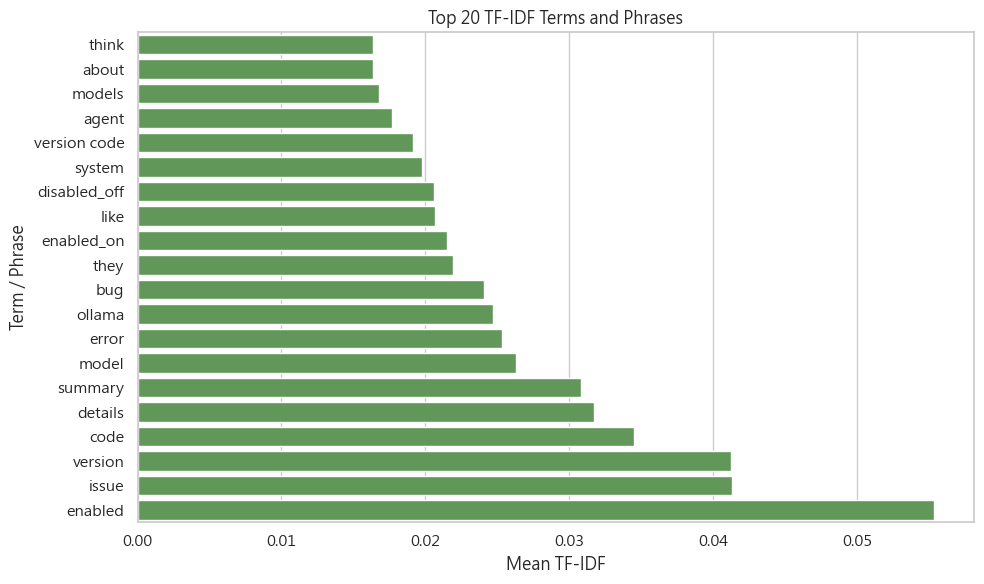

In [ ]:
# 計算 TF-IDF 關鍵詞與片語，找出較具代表性的議題詞。
tfidf_vectorizer = TfidfVectorizer(
    token_pattern=TOKEN_PATTERN,
    stop_words=list(STOP_WORDS),
    min_df=2,
    max_features=1200,
    ngram_range=(1, 2),
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])
tfidf_terms = np.array(tfidf_vectorizer.get_feature_names_out())
tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

top_tfidf = (
    pd.DataFrame({"term": tfidf_terms, "tfidf": tfidf_scores})
    .sort_values("tfidf", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(top_tfidf)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_tfidf.iloc[::-1], x="tfidf", y="term", color="#59A14F")
plt.title("Top 20 TF-IDF Terms and Phrases")
plt.xlabel("Mean TF-IDF")
plt.ylabel("Term / Phrase")
plt.tight_layout()
plt.show()

display(Markdown(
    "TF-IDF 強調能區分文件的代表詞與片語。"
    f"本研究 TF-IDF 最高的項目包含 **{', '.join(top_tfidf['term'].head(5))}**。"
    "這些詞比單純高頻詞更適合用來解釋社群真正聚焦的技術問題與導入風險。"
))


,ngram,count
0,installed version,9089
1,version info,9083
2,installed version info,9081
3,info available,9081
4,version info available,9080
5,version code,4672
6,details summary,4352
7,code version,3750
8,version code version,3652
9,system info,2672


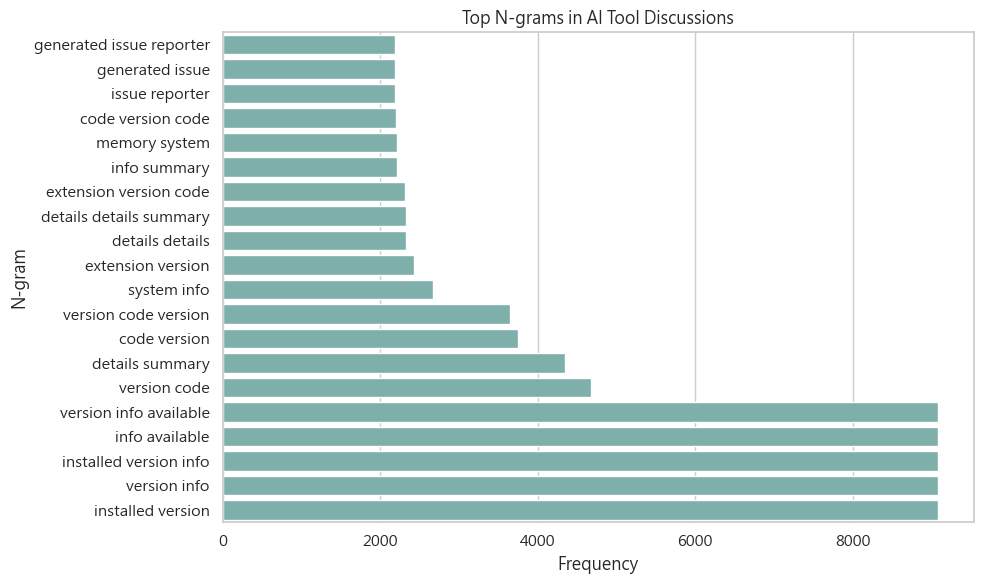

In [ ]:
# 計算常見 N-gram，觀察固定片語與具體問題描述。
ngram_vectorizer = CountVectorizer(
    token_pattern=TOKEN_PATTERN,
    stop_words=list(STOP_WORDS),
    min_df=2,
    max_features=300,
    ngram_range=(2, 3),
)
ngram_matrix = ngram_vectorizer.fit_transform(df["clean_text"])
ngram_terms = np.array(ngram_vectorizer.get_feature_names_out())
ngram_counts = np.asarray(ngram_matrix.sum(axis=0)).ravel()
top_ngrams = (
    pd.DataFrame({"ngram": ngram_terms, "count": ngram_counts})
    .sort_values("count", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(top_ngrams)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_ngrams.iloc[::-1], x="count", y="ngram", color="#76B7B2")
plt.title("Top N-grams in AI Tool Discussions")
plt.xlabel("Frequency")
plt.ylabel("N-gram")
plt.tight_layout()
plt.show()

display(Markdown(
    "N-gram 用於找出固定語言搭配，比單詞更接近具體問題描述。"
    "例如 rate limit、api key、code generation 這類片語，比單看 limit、key、code 更容易解釋管理含義。"
))


,term,document_support
0,issue,0.447496
1,code,0.364272
2,version,0.344407
3,bug,0.283376
4,system,0.240016
5,info,0.227755
6,gpu,0.208918
7,model,0.201863
8,free,0.199123
9,error,0.191040


,rule,support,confidence,lift
0,raw_draw -> video_decode,0.135557,1.000000,7.376958
1,video_decode -> raw_draw,0.135557,1.000000,7.376958
2,raw_draw -> opengl,0.135557,1.000000,7.369510
3,video_decode -> opengl,0.135557,1.000000,7.369510
4,opengl -> raw_draw,0.135557,0.998990,7.369510
5,opengl -> video_decode,0.135557,0.998990,7.369510
6,raw_draw -> argv,0.135420,0.998989,7.369503
7,argv -> raw_draw,0.135420,0.998989,7.369503
8,argv -> video_decode,0.135420,0.998989,7.369503
9,video_decode -> argv,0.135420,0.998989,7.369503


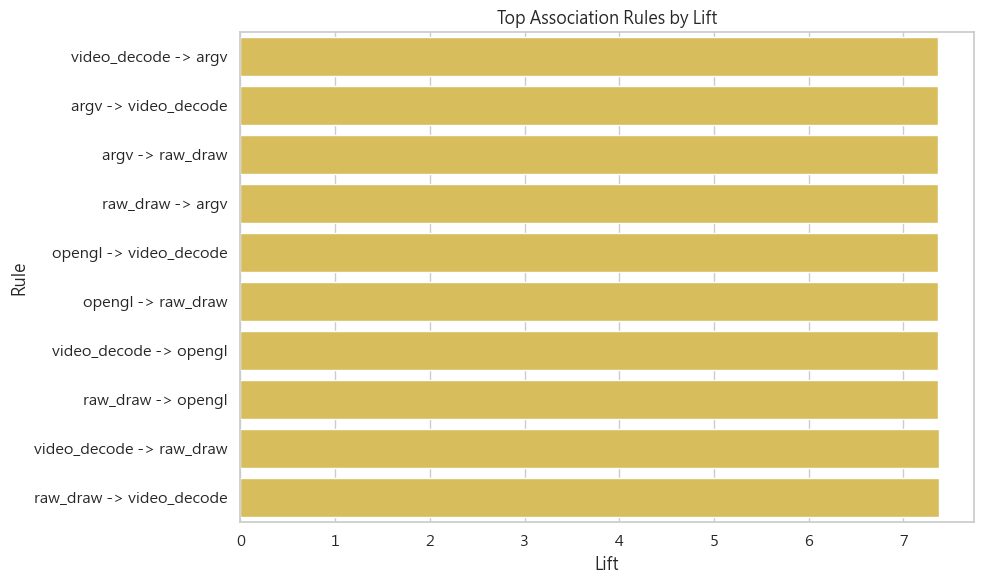

In [ ]:
# 建立 Binary Bag-of-Words 與關聯規則，分析詞彙共現關係。
binary_bow = (count_matrix > 0).astype(int)
binary_term_support = np.asarray(binary_bow.mean(axis=0)).ravel()
binary_bow_summary = (
    pd.DataFrame({"term": terms, "document_support": binary_term_support})
    .sort_values("document_support", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
display(binary_bow_summary)

support_threshold = 0.03
top_rule_term_idx = np.argsort(binary_term_support)[::-1][:40]
rule_rows = []
binary_arr = binary_bow[:, top_rule_term_idx].toarray().astype(bool)
rule_terms = terms[top_rule_term_idx]
for i, j in combinations(range(len(rule_terms)), 2):
    a = binary_arr[:, i]
    b = binary_arr[:, j]
    support_a = a.mean()
    support_b = b.mean()
    support_ab = (a & b).mean()
    if support_ab < support_threshold or support_a == 0 or support_b == 0:
        continue
    confidence_a_to_b = support_ab / support_a
    confidence_b_to_a = support_ab / support_b
    lift = support_ab / (support_a * support_b)
    rule_rows.append(
        {
            "rule": f"{rule_terms[i]} -> {rule_terms[j]}",
            "support": support_ab,
            "confidence": confidence_a_to_b,
            "lift": lift,
        }
    )
    rule_rows.append(
        {
            "rule": f"{rule_terms[j]} -> {rule_terms[i]}",
            "support": support_ab,
            "confidence": confidence_b_to_a,
            "lift": lift,
        }
    )

association_rules = (
    pd.DataFrame(rule_rows)
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .head(15)
    .reset_index(drop=True)
    if rule_rows
    else pd.DataFrame(columns=["rule", "support", "confidence", "lift"])
)
display(association_rules)

if not association_rules.empty:
    plt.figure(figsize=(10, 6))
    plot_rules = association_rules.head(10).iloc[::-1]
    sns.barplot(data=plot_rules, x="lift", y="rule", color="#EDC948")
    plt.title("Top Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Rule")
    plt.tight_layout()
    plt.show()

display(Markdown(
    "Binary Bag-of-Words 與關聯規則用於觀察詞是否共同出現在同一份文件。"
    "Lift 大於 1 表示兩個詞共同出現的程度高於隨機期待，可用來補充議題共現網絡的解釋。"
))


sentiment_label,positive,neutral,negative,total,positive_ratio,neutral_ratio,negative_ratio
source_platform,,,,,,,
GitHub,5145,576,3729,9450,0.544444,0.060952,0.394603
Hacker News,3465,253,1431,5149,0.672946,0.049136,0.277918


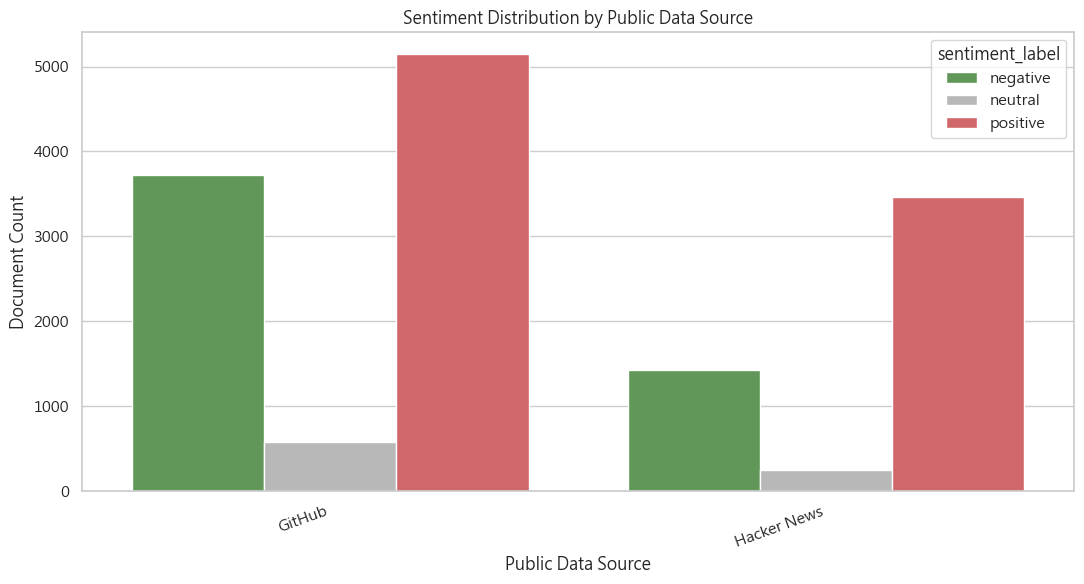

In [ ]:
# 執行情緒分析並比較不同公開資料來源的情緒分布。
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

    vader = SentimentIntensityAnalyzer()
    TECH_LEXICON = {
        "bug": -1.8,
        "crash": -2.2,
        "crashes": -2.2,
        "failed": -1.8,
        "failure": -1.8,
        "broken": -2.0,
        "timeout": -1.4,
        "regression": -1.6,
        "hallucination": -1.8,
        "unsafe": -2.0,
        "leak": -2.0,
        "privacy": -0.8,
        "security": -0.8,
        "fixed": 1.6,
        "resolved": 1.6,
        "works": 1.2,
        "helpful": 1.5,
        "improved": 1.4,
    }
    vader.lexicon.update(TECH_LEXICON)

    def sentiment_score(text):
        return vader.polarity_scores(str(text))["compound"]

    sentiment_method = "VADER with technical lexicon adjustment"
except Exception:
    POSITIVE_WORDS = {
        "fix", "fixed", "resolve", "resolved", "solved", "works", "working",
        "helpful", "great", "good", "better", "improved", "improvement", "stable",
        "success", "successful", "support", "supported", "available", "correct",
        "clear", "useful", "recommended", "fast", "thanks", "thank",
    }
    NEGATIVE_WORDS = {
        "error", "errors", "fail", "failed", "failure", "bug", "bugs", "crash",
        "crashes", "broken", "issue", "issues", "problem", "problems", "wrong",
        "invalid", "denied", "blocked", "stuck", "slow", "timeout", "missing",
        "regression", "unusable", "unsafe", "security", "privacy", "leak", "risk",
        "hallucination", "hallucinate", "incorrect", "confusing", "expensive",
        "quota", "limit", "limits", "rate", "billing",
    }

    def sentiment_score(text):
        tokens = re.findall(TOKEN_PATTERN, str(text).lower())
        if not tokens:
            return 0.0
        pos = sum(token in POSITIVE_WORDS for token in tokens)
        neg = sum(token in NEGATIVE_WORDS for token in tokens)
        return (pos - neg) / math.sqrt(len(tokens))

    sentiment_method = "fallback technical lexicon"


def sentiment_label(score):
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"
    return "neutral"


df["sentiment_score"] = df["text"].map(sentiment_score)
df["sentiment_label"] = df["sentiment_score"].map(sentiment_label)

sentiment_summary = (
    df.groupby(["source_platform", "sentiment_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["positive", "neutral", "negative"], fill_value=0)
)
sentiment_summary["total"] = sentiment_summary.sum(axis=1)
for label in ["positive", "neutral", "negative"]:
    sentiment_summary[f"{label}_ratio"] = sentiment_summary[label] / sentiment_summary["total"]

display(sentiment_summary)
display(Markdown(f"情緒分析使用 **{sentiment_method}**。VADER 較適合英文社群留言；技術詞彙調整讓 bug、crash、timeout、privacy 等工程語境能被更合理地納入情緒判斷。"))

sentiment_plot = (
    df.groupby(["source_platform", "sentiment_label"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(11, 6))
sns.barplot(data=sentiment_plot, x="source_platform", y="count", hue="sentiment_label", palette=["#59A14F", "#B8B8B8", "#E15759"])
plt.title("Sentiment Distribution by Public Data Source")
plt.xlabel("Public Data Source")
plt.ylabel("Document Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

display(Markdown(
    "情緒分布圖用於比較技術 issue 與社群留言的態度差異。GitHub issue 通常偏問題回報，負面詞可能代表維運阻力；"
    "Hacker News 留言較接近輿論討論，正負情緒更能反映支持、懷疑或反彈。"
))


,topic_cluster,topic_label,document_count,top_terms
1,1,模型輸出品質與信任,8632,"they, like, local, issue, model, about, llm, a..."
3,3,錯誤、穩定性與維運,2111,"version, error, code, bug, installed, version ..."
2,2,開發環境與工具整合,1826,"enabled, summary, details, enabled_on, disable..."
0,0,模型輸出品質與信任,981,"ollama, ollama version, gpu, cpu, relevant log..."
5,5,其他實務導入議題,562,"issue, updates discussions, refer issue, issue..."
4,4,錯誤、穩定性與維運,487,"continue, docs, continue docs, bug, reports bu..."


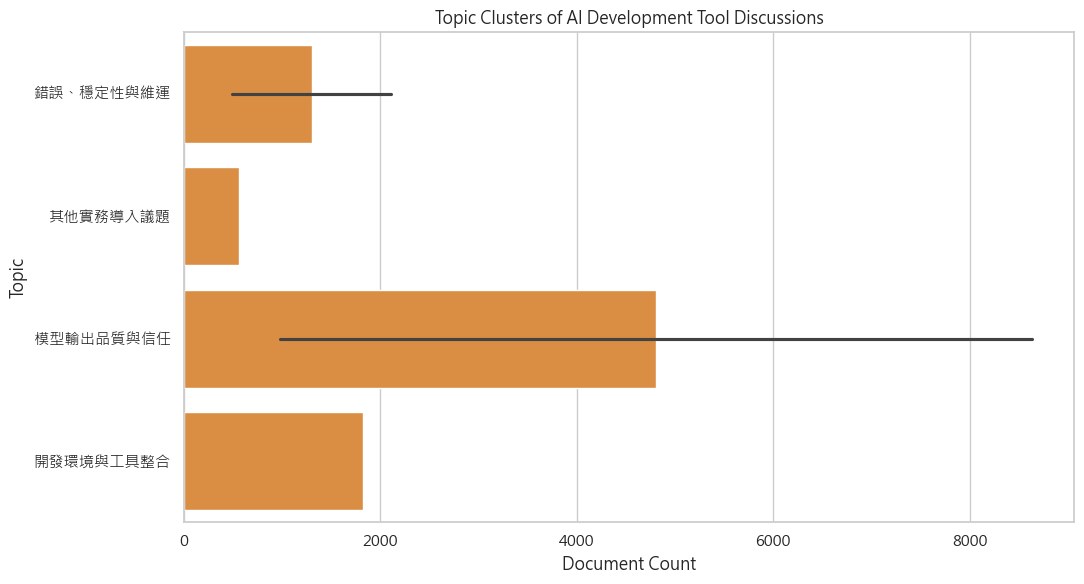

In [ ]:
# 使用 KMeans 進行主題分群，整理各群代表詞與主題名稱。
if len(df) >= 8 and tfidf_matrix.shape[1] >= 8:
    n_topics = min(6, max(2, len(df) // 25))
    model = KMeans(n_clusters=n_topics, random_state=42, n_init=20)
    df["topic_cluster"] = model.fit_predict(tfidf_matrix)

    def infer_topic_label(top_words):
        joined = " ".join(top_words)
        if re.search(r"privacy|security|safe|leak|data|secret|token|key", joined):
            return "資料安全與權限風險"
        if re.search(r"login|auth|authentication|account|permission|access", joined):
            return "登入、權限與帳號管理"
        if re.search(r"error|bug|crash|failed|failure|exception|timeout|regression", joined):
            return "錯誤、穩定性與維運"
        if re.search(r"model|response|suggestion|completion|hallucination|incorrect|quality", joined):
            return "模型輸出品質與信任"
        if re.search(r"billing|quota|rate|limit|price|cost|plan", joined):
            return "成本、額度與服務限制"
        if re.search(r"extension|ide|install|version|workspace|editor|windows|linux|mac", joined):
            return "開發環境與工具整合"
        return "其他實務導入議題"

    cluster_rows = []
    for cluster_id in sorted(df["topic_cluster"].unique()):
        center = model.cluster_centers_[cluster_id]
        top_idx = center.argsort()[::-1][:10]
        words = tfidf_terms[top_idx].tolist()
        cluster_rows.append(
            {
                "topic_cluster": cluster_id,
                "topic_label": infer_topic_label(words),
                "document_count": int((df["topic_cluster"] == cluster_id).sum()),
                "top_terms": ", ".join(words[:8]),
            }
        )
    topic_summary = pd.DataFrame(cluster_rows).sort_values("document_count", ascending=False)
    topic_label_map = topic_summary.set_index("topic_cluster")["topic_label"].to_dict()
    df["topic_label"] = df["topic_cluster"].map(topic_label_map)
else:
    df["topic_cluster"] = 0
    df["topic_label"] = "資料量不足時的合併主題"
    topic_summary = pd.DataFrame(
        [{"topic_cluster": 0, "topic_label": "資料量不足時的合併主題", "document_count": len(df), "top_terms": ""}]
    )

display(topic_summary)

plt.figure(figsize=(11, 6))
topic_plot = topic_summary.sort_values("document_count", ascending=True)
sns.barplot(data=topic_plot, x="document_count", y="topic_label", color="#F28E2B")
plt.title("Topic Clusters of AI Development Tool Discussions")
plt.xlabel("Document Count")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


,lda_topic,document_count,top_terms,representative_title
0,3,6744,"they, like, code, about, one, work, agent, dat...",Calculating tokens prior to prompt
1,2,3917,"ollama, issue, error, bug, model, version, out...",Can't send files - missing purpose
2,0,2817,"enabled, details, summary, version, enabled_on...",VSCode: Can i not uninstall Copilot Chat witho...
3,1,764,"version, info, installed, available, file, cod...",[Bug]: RAPTOR failed due to duplicated Documen...
4,4,357,"false, true, context, debug, trace, model, key...",VSCode: Can i not uninstall Copilot Chat witho...


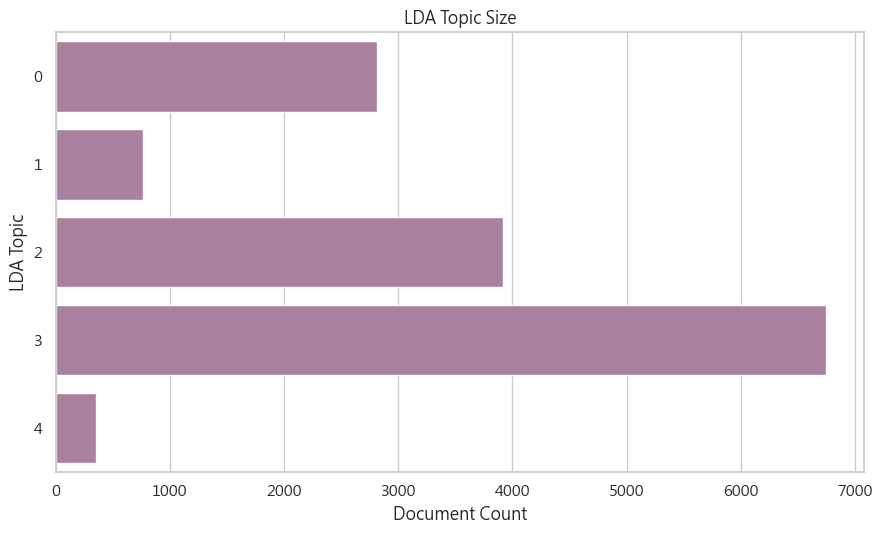

In [ ]:
# 使用 LDA 主題模型作為傳統文字探勘基準。
lda_vectorizer = CountVectorizer(
    token_pattern=TOKEN_PATTERN,
    stop_words=list(STOP_WORDS),
    min_df=2,
    max_features=600,
)
lda_matrix = lda_vectorizer.fit_transform(df["clean_text"])
lda_terms = np.array(lda_vectorizer.get_feature_names_out())
lda_topics = min(5, max(2, len(df) // 45))

lda_model = LatentDirichletAllocation(
    n_components=lda_topics,
    random_state=42,
    learning_method="batch",
    max_iter=20,
)
lda_doc_topic = lda_model.fit_transform(lda_matrix)
df["lda_topic"] = lda_doc_topic.argmax(axis=1)

lda_rows = []
for topic_id, weights in enumerate(lda_model.components_):
    top_idx = weights.argsort()[::-1][:10]
    topic_docs = df[df["lda_topic"].eq(topic_id)]
    lda_rows.append(
        {
            "lda_topic": topic_id,
            "document_count": len(topic_docs),
            "top_terms": ", ".join(lda_terms[top_idx]),
            "representative_title": make_excerpt(topic_docs["title"].iloc[0], 90) if len(topic_docs) else "",
        }
    )
lda_summary = pd.DataFrame(lda_rows).sort_values("document_count", ascending=False).reset_index(drop=True)
display(lda_summary)

plt.figure(figsize=(9, 5.5))
sns.barplot(data=lda_summary.sort_values("document_count"), x="document_count", y="lda_topic", orient="h", color="#B07AA1")
plt.title("LDA Topic Size")
plt.xlabel("Document Count")
plt.ylabel("LDA Topic")
plt.tight_layout()
plt.show()

display(Markdown(
    "LDA 是資料探勘課程常見的詞袋式主題模型。此處將 LDA 作為可解釋的基準方法："
    "它能列出每個主題的代表詞，但對短留言與技術片段容易受高頻詞影響，因此後續再以 BERT 語意分群補強。"
))


In [ ]:
# 整理各主題的代表文件，檢查主題命名是否能被原文支持。
# 主題命名與代表文件證據表

def topic_representative_documents(topic_name, n=2):
    subset = df[df["topic_label"].eq(topic_name)].copy()
    if subset.empty:
        return ""
    sort_columns = [col for col in ["sentiment_score", "word_count"] if col in subset.columns]
    if sort_columns:
        subset = subset.sort_values(sort_columns, ascending=[True if col == "sentiment_score" else False for col in sort_columns]).head(n)
    else:
        subset = subset.head(n)
    items = []
    for _, row in subset.iterrows():
        title = make_excerpt(row.get("title", ""), 70)
        source = row.get("source_platform", "")
        repo = row.get("repo", "")
        items.append(f"[{source}] {repo} - {title}")
    return "；".join(items)

if "topic_summary" in globals() and not topic_summary.empty:
    topic_interpretation = topic_summary.copy()
    topic_interpretation["representative_documents"] = topic_interpretation["topic_label"].map(topic_representative_documents)
    topic_interpretation["naming_reason"] = topic_interpretation["top_terms"].map(
        lambda x: "依據該群 TF-IDF 中心詞與代表文件標題命名；命名以企業導入風險可讀性為優先。"
    )
    topic_interpretation["limitation"] = "自動分群結果仍需人工回看原文，避免將混合議題過度簡化。"
else:
    topic_interpretation = pd.DataFrame(columns=["topic_cluster", "topic_label", "document_count", "top_terms", "representative_documents", "naming_reason", "limitation"])

display(topic_interpretation[["topic_cluster", "topic_label", "document_count", "top_terms", "representative_documents", "naming_reason", "limitation"]])
display(Markdown(
    "主題命名表將模型輸出的 cluster 轉為可管理的風險語言。"
    "命名依據包含 TF-IDF 中心詞、代表文件標題與文件數，並保留限制說明，避免只把演算法結果當成結論。"
))

,topic_cluster,topic_label,document_count,top_terms,representative_documents,naming_reason,limitation
1,1,模型輸出品質與信任,8632,"they, like, local, issue, model, about, llm, a...",[GitHub] continuedev/continue - Unable to buil...,依據該群 TF-IDF 中心詞與代表文件標題命名；命名以企業導入風險可讀性為優先。,自動分群結果仍需人工回看原文，避免將混合議題過度簡化。
3,3,錯誤、穩定性與維運,2111,"version, error, code, bug, installed, version ...",[GitHub] continuedev/continue - Continue.dev E...,依據該群 TF-IDF 中心詞與代表文件標題命名；命名以企業導入風險可讀性為優先。,自動分群結果仍需人工回看原文，避免將混合議題過度簡化。
2,2,開發環境與工具整合,1826,"enabled, summary, details, enabled_on, disable...",[GitHub] microsoft/vscode-copilot-release - So...,依據該群 TF-IDF 中心詞與代表文件標題命名；命名以企業導入風險可讀性為優先。,自動分群結果仍需人工回看原文，避免將混合議題過度簡化。
0,0,模型輸出品質與信任,981,"ollama, ollama version, gpu, cpu, relevant log...",[GitHub] continuedev/continue - Unable to buil...,依據該群 TF-IDF 中心詞與代表文件標題命名；命名以企業導入風險可讀性為優先。,自動分群結果仍需人工回看原文，避免將混合議題過度簡化。
5,5,其他實務導入議題,562,"issue, updates discussions, refer issue, issue...",[GitHub] microsoft/vscode-copilot-release - wt...,依據該群 TF-IDF 中心詞與代表文件標題命名；命名以企業導入風險可讀性為優先。,自動分群結果仍需人工回看原文，避免將混合議題過度簡化。
4,4,錯誤、穩定性與維運,487,"continue, docs, continue docs, bug, reports bu...",[GitHub] continuedev/continue - Continue.dev E...,依據該群 TF-IDF 中心詞與代表文件標題命名；命名以企業導入風險可讀性為優先。,自動分群結果仍需人工回看原文，避免將混合議題過度簡化。


### Embedding 與語意風險分類

這段比較 TF-IDF/SVD 與 Sentence-BERT embedding，並將文件寫入 Qdrant 供語意檢索。


In [ ]:
# 建立企業導入風險類別，並用 TF-IDF/SVD 進行初步風險比對。
RISK_PROFILES = {
    "資料安全與權限風險": "privacy security data leakage secret token api key credential exposure permission access control",
    "模型輸出品質與信任": "incorrect answer hallucination wrong code suggestion quality unreliable response validation review",
    "錯誤、穩定性與維運": "error failed failure crash exception timeout regression broken unavailable stability incident",
    "登入、帳號與授權管理": "login authentication account auth permission license organization user access sign in",
    "成本、額度與服務限制": "quota rate limit billing cost price plan usage limit subscription",
    "開發環境與工具整合": "extension ide editor workspace install version windows linux mac integration configuration",
}

profile_names = list(RISK_PROFILES.keys())
profile_texts = list(RISK_PROFILES.values())

tfidf_profile_matrix = tfidf_vectorizer.transform(profile_texts)
tfidf_risk_scores = cosine_similarity(tfidf_matrix, tfidf_profile_matrix)

svd_components = min(50, max(2, min(tfidf_matrix.shape) - 1))
svd_model = TruncatedSVD(n_components=svd_components, random_state=42)
svd_embeddings = normalize(svd_model.fit_transform(tfidf_matrix))
svd_profile_embeddings = normalize(svd_model.transform(tfidf_profile_matrix))
svd_risk_scores = svd_embeddings @ svd_profile_embeddings.T
svd_explained_variance = float(svd_model.explained_variance_ratio_.sum())

df["tfidf_risk_category"] = [profile_names[i] for i in tfidf_risk_scores.argmax(axis=1)]
df["tfidf_risk_score"] = tfidf_risk_scores.max(axis=1)
df["svd_risk_category"] = [profile_names[i] for i in svd_risk_scores.argmax(axis=1)]
df["svd_risk_score"] = svd_risk_scores.max(axis=1)

display(Markdown(
    f"TF-IDF/SVD embedding 使用 **{svd_components}** 個維度，"
    f"保留 TF-IDF 矩陣約 **{svd_explained_variance:.1%}** 的變異資訊。"
    "此向量適合比較文件相似度，但其語意仍建立在詞彙矩陣之上。"
))


In [ ]:
# 產生或讀取 Sentence-BERT embedding，建立語意風險分類結果。
bert_method = "Sentence-BERT all-MiniLM-L6-v2"
bert_available = True

try:
    os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
    from sentence_transformers import SentenceTransformer

    bert_texts = (
        df["title"].fillna("").astype(str).str.slice(0, 300)
        + " "
        + df["text"].fillna("").astype(str).str.slice(0, 1400)
    ).str.strip().tolist()

    if BERT_EMBEDDING_PATH.exists() and not FORCE_REFRESH_BERT_EMBEDDINGS:
        cached_embeddings = np.load(BERT_EMBEDDING_PATH)
        if cached_embeddings.shape[0] == len(df):
            bert_embeddings = cached_embeddings
        else:
            raise ValueError("cached embedding row count mismatch")
    else:
        raise FileNotFoundError("embedding cache not found or refresh requested")
except Exception:
    try:
        model = SentenceTransformer(BERT_MODEL_NAME)
        bert_embeddings = model.encode(
            bert_texts,
            normalize_embeddings=True,
            batch_size=16,
            show_progress_bar=False,
        )
        DATA_DIR.mkdir(exist_ok=True)
        np.save(BERT_EMBEDDING_PATH, bert_embeddings)
    except Exception as exc:
        bert_available = False
        bert_method = "TF-IDF/SVD fallback"
        bert_embeddings = svd_embeddings
        bert_load_error = str(exc)

if bert_available:
    model = SentenceTransformer(BERT_MODEL_NAME)
    bert_profile_embeddings = model.encode(
        profile_texts,
        normalize_embeddings=True,
        batch_size=16,
        show_progress_bar=False,
    )
    semantic_scores = bert_embeddings @ bert_profile_embeddings.T
else:
    semantic_scores = svd_risk_scores

df["semantic_risk_category"] = [profile_names[i] for i in semantic_scores.argmax(axis=1)]
df["semantic_risk_score"] = semantic_scores.max(axis=1)

method_note = (
    f"本研究已使用 **{bert_method}** 產生文件語意向量。"
    if bert_available
    else f"Sentence-BERT 未能載入，因此本次以 SVD embedding 作為語意向量替代。錯誤摘要：`{bert_load_error[:180]}`"
)
display(Markdown(method_note))



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4067.19it/s]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 25750.33it/s]

In [ ]:
# 將文件 embedding 寫入本機 Qdrant，建立語意檢索索引。
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams

qdrant_rebuild_reason = "reused_existing_collection"
qdrant_expected_count = len(df)
qdrant_vector_size = int(bert_embeddings.shape[1])
qdrant_ready = False

try:
    qdrant_client = QdrantClient(path=str(QDRANT_PATH))
    collection_exists = qdrant_client.collection_exists(QDRANT_COLLECTION)
    existing_count = 0
    if collection_exists:
        existing_count = qdrant_client.count(QDRANT_COLLECTION, exact=True).count

    if FORCE_REBUILD_QDRANT or (not collection_exists) or existing_count != qdrant_expected_count:
        if collection_exists:
            qdrant_client.delete_collection(QDRANT_COLLECTION)
        qdrant_client.create_collection(
            collection_name=QDRANT_COLLECTION,
            vectors_config=VectorParams(size=qdrant_vector_size, distance=Distance.COSINE),
        )

        points = []
        for idx, row in df.reset_index(drop=True).iterrows():
            payload = {
                "row_index": int(idx),
                "source_platform": str(row.get("source_platform", "")),
                "repo": str(row.get("repo", "")),
                "source_type": str(row.get("source_type", "")),
                "title": str(row.get("title", ""))[:300],
                "text_excerpt": make_excerpt(row.get("text", ""), 500),
                "user": str(row.get("user", "")),
                "created_at": str(row.get("created_at", "")),
                "sentiment_label": str(row.get("sentiment_label", "")),
                "semantic_risk_category": str(row.get("semantic_risk_category", "")),
                "topic_label": str(row.get("topic_label", "")),
                "url": str(row.get("url", "")),
            }
            points.append(
                PointStruct(
                    id=int(idx),
                    vector=bert_embeddings[idx].astype(float).tolist(),
                    payload=payload,
                )
            )

        batch_size = 128
        for start in range(0, len(points), batch_size):
            qdrant_client.upsert(
                collection_name=QDRANT_COLLECTION,
                points=points[start : start + batch_size],
            )
        qdrant_rebuild_reason = "rebuilt_forced" if FORCE_REBUILD_QDRANT else "rebuilt_missing_or_count_changed"

    qdrant_count = qdrant_client.count(QDRANT_COLLECTION, exact=True).count
    qdrant_ready = qdrant_count == qdrant_expected_count
    display(Markdown(
        f"Qdrant local collection `{QDRANT_COLLECTION}` 已就緒，路徑為 `{QDRANT_PATH.as_posix()}`。"
        f"目前向量筆數為 **{qdrant_count:,}**，向量維度為 **{qdrant_vector_size}**，狀態為 `{qdrant_rebuild_reason}`。"
    ))
finally:
    try:
        qdrant_client.close()
    except Exception:
        pass


In [ ]:
# 定義 Qdrant 語意搜尋函式，查詢與風險描述相近的文件。
def semantic_search_qdrant(query_text, limit=5):
    query_vector = model.encode([query_text], normalize_embeddings=True, show_progress_bar=False)[0]
    client = QdrantClient(path=str(QDRANT_PATH))
    try:
        result = client.query_points(
            collection_name=QDRANT_COLLECTION,
            query=query_vector.astype(float).tolist(),
            limit=limit,
            with_payload=True,
        )
        rows = []
        for point in result.points:
            payload = point.payload or {}
            rows.append(
                {
                    "query": query_text,
                    "row_index": payload.get("row_index"),
                    "score": round(float(point.score), 4),
                    "source": payload.get("source_platform"),
                    "repo": payload.get("repo"),
                    "sentiment": payload.get("sentiment_label"),
                    "risk_category": payload.get("semantic_risk_category"),
                    "title": payload.get("title"),
                    "excerpt": payload.get("text_excerpt"),
                    "url": payload.get("url"),
                }
            )
        return pd.DataFrame(rows)
    finally:
        client.close()


qdrant_queries = [
    "developers worry about sending private source code or API keys to AI tools",
    "AI coding assistant gives wrong or hallucinated code suggestions",
    "rate limits billing quota and subscription cost problems",
]
qdrant_results = pd.concat([semantic_search_qdrant(query, limit=5) for query in qdrant_queries], ignore_index=True)
display(qdrant_results)

display(Markdown(
    "Qdrant 查詢表展示此專題可延伸到企業知識庫或 RAG 前置架構："
    "當公司累積內部需求單、維運紀錄或 AI 工具試用回饋後，可將文件 embedding 寫入 Qdrant，"
    "用自然語言查詢相似案例、常見風險與處理紀錄。"
))


,query,row_index,score,source,repo,sentiment,risk_category,title,excerpt,url
0,developers worry about sending private source ...,9794,0.6103,Hacker News,Hacker News / data privacy AI coding,positive,資料安全與權限風險,Developers spend most of their time figuring t...,Developers spend most of their time figuring t...,https://news.ycombinator.com/item?id=44068384
1,developers worry about sending private source ...,9477,0.5499,Hacker News,Hacker News / data privacy AI coding,positive,資料安全與權限風險,Show HN: AI co-worker for system software deve...,Show HN: AI co-worker for system software deve...,https://news.ycombinator.com/item?id=41237250
2,developers worry about sending private source ...,12113,0.5489,Hacker News,Hacker News / prompt injection,positive,資料安全與權限風險,CISA Admin Leaked AWS GovCloud Keys on GitHub,CISA Admin Leaked AWS GovCloud Keys on GitHub ...,https://news.ycombinator.com/item?id=48194675
3,developers worry about sending private source ...,12218,0.5458,Hacker News,Hacker News / AI agent,positive,模型輸出品質與信任,"GitHub confirms breach of 3,800 repos via mali...","GitHub confirms breach of 3,800 repos via mali...",https://news.ycombinator.com/item?id=48224529
4,developers worry about sending private source ...,12500,0.5450,Hacker News,Hacker News / AI agent,negative,資料安全與權限風險,- -dangerously-skip-reading-code,- -dangerously-skip-reading-code Leaking crede...,https://news.ycombinator.com/item?id=48251425
5,AI coding assistant gives wrong or hallucinate...,1288,0.6081,GitHub,microsoft/vscode-copilot-release,positive,錯誤、穩定性與維運,AI is so bad after the last few update I can't...,Thanks for creating this issue! We figured it'...,https://github.com/microsoft/vscode-copilot-re...
6,AI coding assistant gives wrong or hallucinate...,11855,0.6034,Hacker News,Hacker News / AI coding assistant,negative,模型輸出品質與信任,"An AI coding agent, used to write code, needs ...","An AI coding agent, used to write code, needs ...",https://news.ycombinator.com/item?id=48096211
7,AI coding assistant gives wrong or hallucinate...,12449,0.5877,Hacker News,Hacker News / AI agent,positive,模型輸出品質與信任,Twelve Ways to Be Wrong About AI-Assisted Coding,Twelve Ways to Be Wrong About AI-Assisted Codi...,https://news.ycombinator.com/item?id=48245981
8,AI coding assistant gives wrong or hallucinate...,4834,0.5873,GitHub,microsoft/vscode-copilot-release,positive,模型輸出品質與信任,AI is so bad after the last few update I can't...,AI is so bad after the last few update I can't...,https://github.com/microsoft/vscode-copilot-re...
9,AI coding assistant gives wrong or hallucinate...,12013,0.5802,Hacker News,Hacker News / AI coding assistant,positive,模型輸出品質與信任,I believe there are entire companies right now...,I believe there are entire companies right now...,https://news.ycombinator.com/item?id=48157696


### 圖譜定義

這段定義使用者互動、關鍵詞共現、repo-topic 與 Graph RAG 證據圖的節點、邊與解讀方式。


### Graph RAG 證據整理

這段以 Qdrant 召回相似文件，再用圖關係補充風險、主題、關鍵詞與來源證據。


In [ ]:
# 建立 Graph RAG 證據圖，連結文件、主題、風險、情緒與關鍵詞。
evidence_graph = nx.Graph()

doc_top_terms = {}
for doc_idx in range(tfidf_matrix.shape[0]):
    row = tfidf_matrix.getrow(doc_idx)
    if row.nnz == 0:
        doc_top_terms[doc_idx] = []
        continue
    top_local_idx = np.argsort(row.data)[::-1][:5]
    doc_top_terms[doc_idx] = [tfidf_terms[row.indices[i]] for i in top_local_idx if row.data[i] > 0]

for idx, row in df.reset_index(drop=True).iterrows():
    doc_node = f"doc:{idx}"
    evidence_graph.add_node(
        doc_node,
        node_type="document",
        label=f"D{idx}",
        title=make_excerpt(row.get("title", ""), 80),
        source=row.get("source_platform", ""),
    )

    connected_nodes = [
        ("source", str(row.get("source_platform", ""))),
        ("risk", str(row.get("semantic_risk_category", ""))),
        ("topic", str(row.get("topic_label", ""))),
        ("sentiment", str(row.get("sentiment_label", ""))),
    ]
    for kind, value in connected_nodes:
        if not value or value == "nan":
            continue
        node = f"{kind}:{value}"
        evidence_graph.add_node(node, node_type=kind, label=value)
        evidence_graph.add_edge(doc_node, node, relation=kind, weight=1)

    for term in doc_top_terms.get(idx, []):
        node = f"term:{term}"
        evidence_graph.add_node(node, node_type="term", label=term)
        evidence_graph.add_edge(doc_node, node, relation="keyword", weight=1)

display(Markdown(
    f"Graph-RAG evidence graph 已建立：**{evidence_graph.number_of_nodes():,}** 個節點、"
    f"**{evidence_graph.number_of_edges():,}** 條邊。節點包含文件、關鍵詞、風險類別、主題、情緒與資料來源。"
))


,query,row_index,combined_score,semantic_score,graph_score,source,sentiment,risk_category,topic,graph_reasons,title,excerpt,url
0,private source code leaked through AI coding a...,10962,0.7255,0.6079,36.0,Hacker News,positive,資料安全與權限風險,模型輸出品質與信任,risk:資料安全與權限風險; sentiment:positive; source:Hac...,Claude Code's source code has been leaked via ...,Claude Code's source code has been leaked via ...,https://news.ycombinator.com/item?id=47587707
1,private source code leaked through AI coding a...,10963,0.7146,0.5923,36.0,Hacker News,positive,資料安全與權限風險,模型輸出品質與信任,risk:資料安全與權限風險; sentiment:positive; source:Hac...,Claude Code's source code has been leaked via ...,Claude Code's source code has been leaked via ...,https://news.ycombinator.com/item?id=47590491
2,private source code leaked through AI coding a...,9477,0.6859,0.5870,33.0,Hacker News,positive,資料安全與權限風險,模型輸出品質與信任,risk:資料安全與權限風險; sentiment:positive; source:Hac...,Show HN: AI co-worker for system software deve...,Show HN: AI co-worker for system software deve...,https://news.ycombinator.com/item?id=41237250
3,private source code leaked through AI coding a...,12452,0.6623,0.5532,33.0,Hacker News,positive,模型輸出品質與信任,模型輸出品質與信任,risk:模型輸出品質與信任; sentiment:positive; source:Hac...,I reproduced a Claude Code RCE. The bug patter...,I reproduced a Claude Code RCE. The bug patter...,https://news.ycombinator.com/item?id=48246311
4,private source code leaked through AI coding a...,12218,0.6610,0.5752,31.0,Hacker News,positive,模型輸出品質與信任,模型輸出品質與信任,risk:模型輸出品質與信任; sentiment:positive; source:Hac...,"GitHub confirms breach of 3,800 repos via mali...","GitHub confirms breach of 3,800 repos via mali...",https://news.ycombinator.com/item?id=48224529
5,private source code leaked through AI coding a...,13254,0.6468,0.5668,30.0,Hacker News,neutral,資料安全與權限風險,模型輸出品質與信任,risk:資料安全與權限風險; sentiment:neutral; source:Hack...,Protestware for coding agents,Protestware for coding agents Maybe defend aga...,https://news.ycombinator.com/item?id=48320943
6,private source code leaked through AI coding a...,13247,0.6358,0.5749,28.0,Hacker News,negative,登入、帳號與授權管理,模型輸出品質與信任,risk:登入、帳號與授權管理; sentiment:negative; source:Ha...,Protestware for coding agents,Protestware for coding agents I think a lot tu...,https://news.ycombinator.com/item?id=48320736
7,private source code leaked through AI coding a...,12481,0.6181,0.5496,28.0,Hacker News,positive,資料安全與權限風險,模型輸出品質與信任,risk:資料安全與權限風險; sentiment:positive; source:Hac...,Show HN: I built a powerful RAG and knowledge ...,Show HN: I built a powerful RAG and knowledge ...,https://news.ycombinator.com/item?id=48249188
8,private source code leaked through AI coding a...,7336,0.6000,0.5833,23.0,GitHub,negative,模型輸出品質與信任,模型輸出品質與信任,risk:模型輸出品質與信任; sentiment:negative; source:Git...,Removes random code without reason - Github is...,I'm now dealing with incredibly stubborn AI ag...,https://github.com/microsoft/vscode-copilot-re...
9,private source code leaked through AI coding a...,9794,0.5818,0.5335,25.0,Hacker News,positive,資料安全與權限風險,模型輸出品質與信任,risk:資料安全與權限風險; sentiment:positive; source:Hac...,Developers spend most of their time figuring t...,Developers spend most of their time figuring t...,https://news.ycombinator.com/item?id=44068384


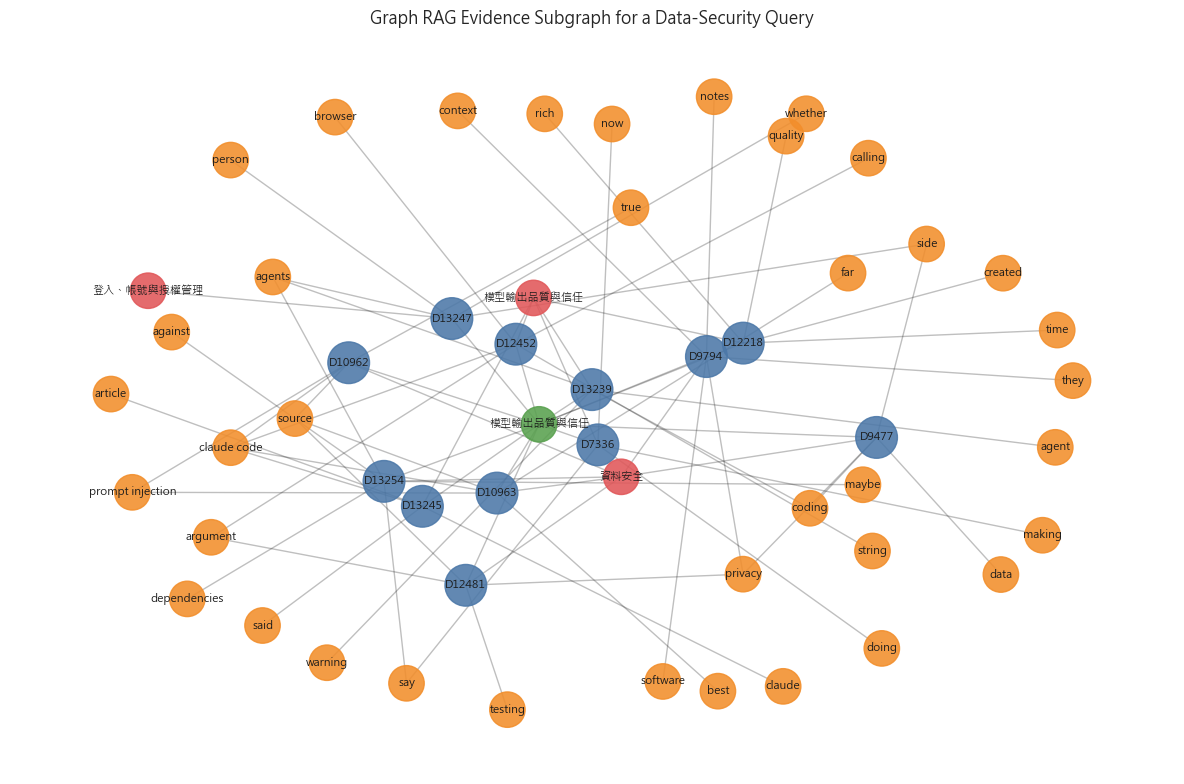

In [ ]:
# 執行 Graph RAG 檢索，結合向量相似度與圖上共同證據。
def graph_rag_retrieve(query_text, seed_limit=8, final_limit=12):
    seed_results = semantic_search_qdrant(query_text, limit=seed_limit)
    if seed_results.empty:
        return pd.DataFrame(), []

    query_vector = model.encode([query_text], normalize_embeddings=True, show_progress_bar=False)[0]
    query_scores = bert_embeddings @ query_vector
    seed_indices = [int(x) for x in seed_results["row_index"].dropna().tolist()]

    candidate_scores = Counter()
    candidate_reasons = {}
    for seed_idx in seed_indices:
        seed_node = f"doc:{seed_idx}"
        if seed_node not in evidence_graph:
            continue
        neighbor_nodes = list(evidence_graph.neighbors(seed_node))
        for neighbor in neighbor_nodes:
            relation = evidence_graph.nodes[neighbor].get("node_type", "")
            label = evidence_graph.nodes[neighbor].get("label", neighbor)
            for candidate_node in evidence_graph.neighbors(neighbor):
                if not candidate_node.startswith("doc:"):
                    continue
                candidate_idx = int(candidate_node.split(":", 1)[1])
                candidate_scores[candidate_idx] += 1.0
                candidate_reasons.setdefault(candidate_idx, set()).add(f"{relation}:{label}")

    for seed_idx in seed_indices:
        candidate_scores[seed_idx] += 3.0
        candidate_reasons.setdefault(seed_idx, set()).add("vector_seed")

    if not candidate_scores:
        return seed_results, []

    max_graph_score = max(candidate_scores.values()) or 1.0
    rows = []
    for candidate_idx, graph_score in candidate_scores.items():
        row = df.iloc[candidate_idx]
        semantic_score = float(query_scores[candidate_idx])
        combined_score = 0.7 * semantic_score + 0.3 * (graph_score / max_graph_score)
        rows.append(
            {
                "query": query_text,
                "row_index": candidate_idx,
                "combined_score": round(combined_score, 4),
                "semantic_score": round(semantic_score, 4),
                "graph_score": round(graph_score, 2),
                "source": row.get("source_platform", ""),
                "sentiment": row.get("sentiment_label", ""),
                "risk_category": row.get("semantic_risk_category", ""),
                "topic": row.get("topic_label", ""),
                "graph_reasons": "; ".join(sorted(candidate_reasons.get(candidate_idx, []))[:8]),
                "title": make_excerpt(row.get("title", ""), 100),
                "excerpt": make_excerpt(row.get("text", ""), 220),
                "url": row.get("url", ""),
            }
        )

    result_df = (
        pd.DataFrame(rows)
        .sort_values(["combined_score", "semantic_score", "graph_score"], ascending=False)
        .head(final_limit)
        .reset_index(drop=True)
    )
    selected_nodes = {f"doc:{idx}" for idx in result_df["row_index"].astype(int).tolist()}
    for doc_node in list(selected_nodes):
        if doc_node in evidence_graph:
            useful_neighbors = [
                n for n in evidence_graph.neighbors(doc_node)
                if evidence_graph.nodes[n].get("node_type") in {"risk", "topic", "term"}
            ][:6]
            selected_nodes.update(useful_neighbors)
    return result_df, list(selected_nodes)


graph_rag_query = "private source code leaked through AI coding assistant"
graph_rag_results, graph_rag_nodes = graph_rag_retrieve(graph_rag_query, seed_limit=8, final_limit=12)
display(graph_rag_results)

if graph_rag_nodes:
    sub = evidence_graph.subgraph(graph_rag_nodes).copy()
    color_map = {
        "document": "#4C78A8",
        "term": "#F28E2B",
        "risk": "#E15759",
        "topic": "#59A14F",
    }
    node_colors = [color_map.get(sub.nodes[n].get("node_type"), "#B8B8B8") for n in sub.nodes()]
    node_sizes = [900 if sub.nodes[n].get("node_type") == "document" else 650 for n in sub.nodes()]
    labels = {n: sub.nodes[n].get("label", n).replace("資料安全與權限風險", "資料安全")[:18] for n in sub.nodes()}
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(sub, seed=42, k=0.9)
    nx.draw_networkx_nodes(sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.88)
    nx.draw_networkx_edges(sub, pos, alpha=0.28)
    nx.draw_networkx_labels(sub, pos, labels=labels, font_size=8)
    plt.title("Graph RAG Evidence Subgraph for a Data-Security Query")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

display(Markdown(
    "Graph RAG 證據表與子圖的用途是解釋檢索結果為什麼相關。"
    "向量檢索提供語意相似文件，圖擴展補上共同風險、共同主題與共同關鍵詞，"
    "因此比單純列出 embedding 相似度更適合用於企業導入風險盤點。"
))


In [ ]:
# 評估 Graph RAG 結果，確認檢索證據與風險分類的一致性。
# Graph RAG 檢索品質與來源檢核表

if "graph_rag_results" in globals() and not graph_rag_results.empty:
    graph_rag_audit = graph_rag_results.head(10).copy()
    graph_rag_audit["has_source_url"] = graph_rag_audit["url"].fillna("").astype(str).str.startswith("http")
    graph_rag_audit["has_excerpt"] = graph_rag_audit["excerpt"].fillna("").astype(str).str.len() >= 40
    graph_rag_audit["has_graph_reason"] = graph_rag_audit["graph_reasons"].fillna("").astype(str).str.len() > 0
    graph_rag_audit["manual_relevance_check"] = np.where(
        (graph_rag_audit["combined_score"] >= graph_rag_audit["combined_score"].median())
        & graph_rag_audit["has_excerpt"]
        & graph_rag_audit["has_graph_reason"],
        "high-priority evidence",
        "review original text",
    )
    graph_rag_audit_summary = pd.DataFrame(
        [
            {"check_item": "Top-k results with source URL", "passed": int(graph_rag_audit["has_source_url"].sum()), "total": len(graph_rag_audit)},
            {"check_item": "Top-k results with usable excerpt", "passed": int(graph_rag_audit["has_excerpt"].sum()), "total": len(graph_rag_audit)},
            {"check_item": "Top-k results with graph reason", "passed": int(graph_rag_audit["has_graph_reason"].sum()), "total": len(graph_rag_audit)},
        ]
    )
else:
    graph_rag_audit = pd.DataFrame(columns=["query", "row_index", "combined_score", "semantic_score", "graph_score", "has_source_url", "has_excerpt", "has_graph_reason", "manual_relevance_check"])
    graph_rag_audit_summary = pd.DataFrame(columns=["check_item", "passed", "total"])

display(graph_rag_audit_summary)
display(graph_rag_audit[["query", "row_index", "combined_score", "semantic_score", "graph_score", "source", "risk_category", "has_source_url", "has_excerpt", "has_graph_reason", "manual_relevance_check", "title", "url"]])
display(Markdown(
    "Graph RAG 評估重點在於檢索結果是否可追溯，而不是只看模型生成摘要。"
    "因此本研究檢查 Top-k 結果是否具備來源 URL、可讀 excerpt 與 graph reason；"
    "若任一項不足，企業應回到原文人工確認，不應直接把檢索結果當成決策結論。"
))

,check_item,passed,total
0,Top-k results with source URL,10,10
1,Top-k results with usable excerpt,10,10
2,Top-k results with graph reason,10,10


,query,row_index,combined_score,semantic_score,graph_score,source,risk_category,has_source_url,has_excerpt,has_graph_reason,manual_relevance_check,title,url
0,private source code leaked through AI coding a...,10962,0.7255,0.6079,36.0,Hacker News,資料安全與權限風險,True,True,True,high-priority evidence,Claude Code's source code has been leaked via ...,https://news.ycombinator.com/item?id=47587707
1,private source code leaked through AI coding a...,10963,0.7146,0.5923,36.0,Hacker News,資料安全與權限風險,True,True,True,high-priority evidence,Claude Code's source code has been leaked via ...,https://news.ycombinator.com/item?id=47590491
2,private source code leaked through AI coding a...,9477,0.6859,0.5870,33.0,Hacker News,資料安全與權限風險,True,True,True,high-priority evidence,Show HN: AI co-worker for system software deve...,https://news.ycombinator.com/item?id=41237250
3,private source code leaked through AI coding a...,12452,0.6623,0.5532,33.0,Hacker News,模型輸出品質與信任,True,True,True,high-priority evidence,I reproduced a Claude Code RCE. The bug patter...,https://news.ycombinator.com/item?id=48246311
4,private source code leaked through AI coding a...,12218,0.6610,0.5752,31.0,Hacker News,模型輸出品質與信任,True,True,True,high-priority evidence,"GitHub confirms breach of 3,800 repos via mali...",https://news.ycombinator.com/item?id=48224529
5,private source code leaked through AI coding a...,13254,0.6468,0.5668,30.0,Hacker News,資料安全與權限風險,True,True,True,review original text,Protestware for coding agents,https://news.ycombinator.com/item?id=48320943
6,private source code leaked through AI coding a...,13247,0.6358,0.5749,28.0,Hacker News,登入、帳號與授權管理,True,True,True,review original text,Protestware for coding agents,https://news.ycombinator.com/item?id=48320736
7,private source code leaked through AI coding a...,12481,0.6181,0.5496,28.0,Hacker News,資料安全與權限風險,True,True,True,review original text,Show HN: I built a powerful RAG and knowledge ...,https://news.ycombinator.com/item?id=48249188
8,private source code leaked through AI coding a...,7336,0.6000,0.5833,23.0,GitHub,模型輸出品質與信任,True,True,True,review original text,Removes random code without reason - Github is...,https://github.com/microsoft/vscode-copilot-re...
9,private source code leaked through AI coding a...,9794,0.5818,0.5335,25.0,Hacker News,資料安全與權限風險,True,True,True,review original text,Developers spend most of their time figuring t...,https://news.ycombinator.com/item?id=44068384


In [ ]:
# 檢查 Ollama 本機模型狀態，必要時產生本機摘要。
def ollama_model_available(model_name):
    try:
        result = subprocess.run(
            ["ollama", "list"],
            capture_output=True,
            text=True,
            timeout=20,
            check=False,
        )
        if result.returncode != 0:
            return False, result.stderr.strip()[:200]
        return model_name.split(":")[0] in result.stdout or model_name in result.stdout, result.stdout.strip()
    except Exception as exc:
        return False, str(exc)[:200]


def summarize_with_ollama(evidence_df, model_name=OLLAMA_MODEL):
    evidence_lines = []
    for i, row in evidence_df.head(8).iterrows():
        evidence_lines.append(
            f"[{i+1}] source={row['source']} risk={row['risk_category']} sentiment={row['sentiment']} "
            f"title={row['title']} excerpt={row['excerpt']}"
        )
    prompt = (
        "你是企業資訊系統導入 AI 工具的分析助理。"
        "請只能根據下列證據，用繁體中文整理：1. 主要風險 2. 支持證據 3. 導入建議。"
        "不要補充證據中沒有的事。\n\n"
        + "\n".join(evidence_lines)
    )
    result = subprocess.run(
        ["ollama", "run", model_name, prompt],
        capture_output=True,
        text=True,
        timeout=180,
        check=False,
    )
    if result.returncode != 0:
        return f"Ollama 執行失敗：{result.stderr.strip()[:300]}"
    return result.stdout.strip()


model_available, ollama_status = ollama_model_available(OLLAMA_MODEL)
display(Markdown(
    f"Ollama 摘要參數：`USE_OLLAMA_SUMMARY = {USE_OLLAMA_SUMMARY}`，"
    f"`OLLAMA_MODEL = {OLLAMA_MODEL}`，模型可用狀態：`{model_available}`。"
))

if USE_OLLAMA_SUMMARY and model_available and not graph_rag_results.empty:
    ollama_summary = summarize_with_ollama(graph_rag_results, OLLAMA_MODEL)
    display(Markdown("#### Ollama 本機 Graph RAG 摘要"))
    display(Markdown(ollama_summary))
else:
    display(Markdown(
        "本次未產生 Ollama 摘要。若要啟用，可先在 PowerShell 執行 "
        "`ollama pull llama3.2:3b`，再將 Notebook 參數 `USE_OLLAMA_SUMMARY` 改為 `True`。"
        "此步驟為可選功能，不影響文字探勘、Qdrant 與 Graph RAG 證據表結果。"
    ))


,TF-IDF,TF-IDF/SVD embedding,Sentence-BERT embedding
資料安全與權限風險,5728,1741,1787
模型輸出品質與信任,2453,2931,2706
錯誤、穩定性與維運,1726,1480,5491
登入、帳號與授權管理,763,2112,382
成本、額度與服務限制,848,2314,1214
開發環境與工具整合,3081,4021,3019


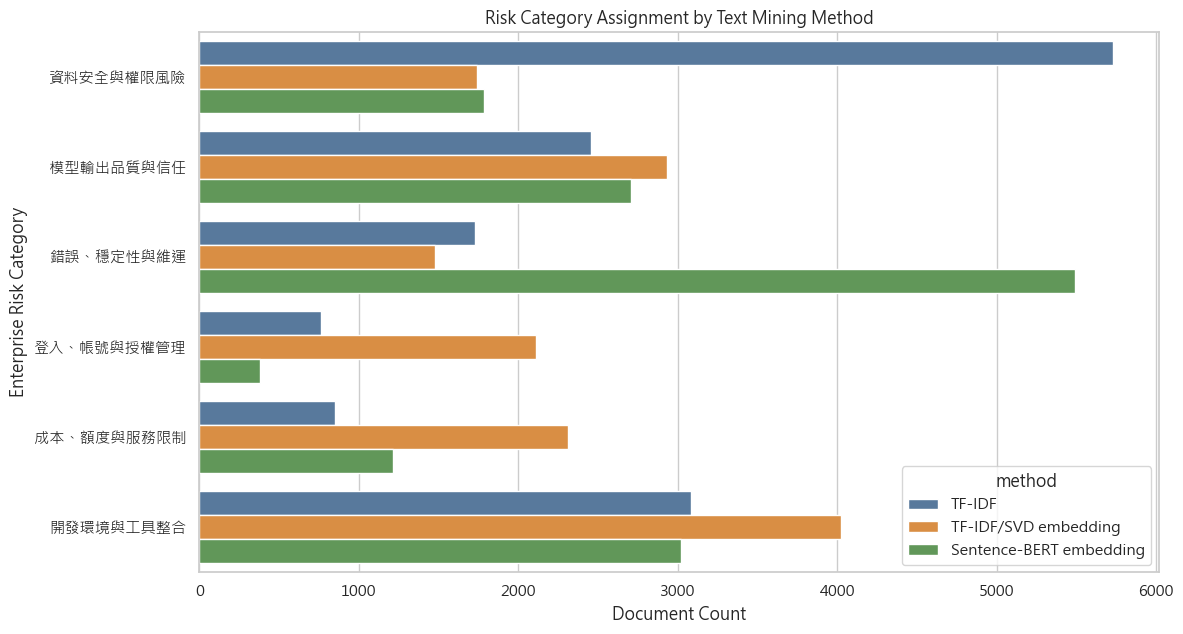

In [ ]:
# 比較 TF-IDF、SVD 與 BERT 對風險分類的差異。
method_distribution = pd.concat(
    [
        df["tfidf_risk_category"].value_counts().rename("TF-IDF"),
        df["svd_risk_category"].value_counts().rename("TF-IDF/SVD embedding"),
        df["semantic_risk_category"].value_counts().rename("Sentence-BERT embedding"),
    ],
    axis=1,
).fillna(0).astype(int)
method_distribution = method_distribution.reindex(profile_names).fillna(0).astype(int)
display(method_distribution)

method_distribution_long = (
    method_distribution
    .reset_index(names="risk_category")
    .melt(id_vars="risk_category", var_name="method", value_name="document_count")
)

plt.figure(figsize=(12, 6.5))
sns.barplot(
    data=method_distribution_long,
    x="document_count",
    y="risk_category",
    hue="method",
    palette=["#4C78A8", "#F28E2B", "#59A14F"],
)
plt.title("Risk Category Assignment by Text Mining Method")
plt.xlabel("Document Count")
plt.ylabel("Enterprise Risk Category")
plt.tight_layout()
plt.show()

display(Markdown(
    "此圖比較三種方法對同一批文件的風險歸類。"
    "若 TF-IDF 與 BERT 差異很大，代表部分討論並非只靠字面關鍵詞即可掌握；"
    "若兩者接近，表示該風險議題具有明確且穩定的詞彙訊號。"
))


,document_count,avg_semantic_score,negative_documents,neutral_documents,positive_documents,negative_ratio
semantic_risk_category,,,,,,
錯誤、穩定性與維運,5491,0.250548,2366,222,2903,0.430887
模型輸出品質與信任,2706,0.170310,902,140,1664,0.333333
資料安全與權限風險,1787,0.171313,589,92,1106,0.329603
開發環境與工具整合,3019,0.181093,868,231,1920,0.287512
登入、帳號與授權管理,382,0.260020,106,57,219,0.277487
成本、額度與服務限制,1214,0.181156,329,87,798,0.271005


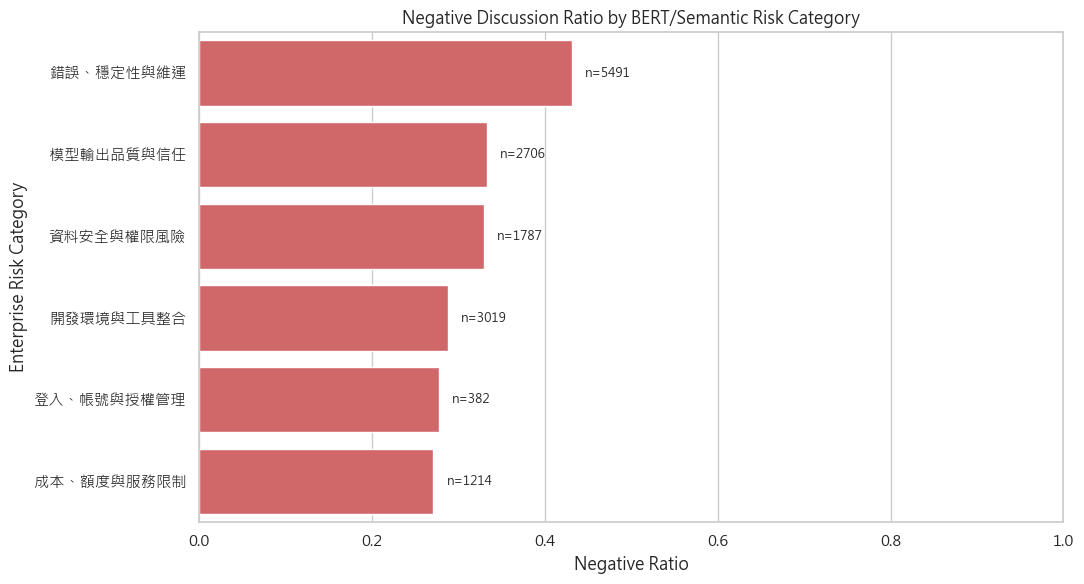

In [ ]:
# 彙整各風險類別的文件量、語意分數與負面比例。
semantic_risk_summary = (
    df.groupby("semantic_risk_category")
    .agg(
        document_count=("semantic_risk_category", "size"),
        avg_semantic_score=("semantic_risk_score", "mean"),
        negative_documents=("sentiment_label", lambda x: int((x == "negative").sum())),
        neutral_documents=("sentiment_label", lambda x: int((x == "neutral").sum())),
        positive_documents=("sentiment_label", lambda x: int((x == "positive").sum())),
    )
    .assign(negative_ratio=lambda x: x["negative_documents"] / x["document_count"])
    .reindex(profile_names)
    .dropna(subset=["document_count"])
    .sort_values(["negative_ratio", "document_count"], ascending=False)
)

display(semantic_risk_summary)

plt.figure(figsize=(11, 6))
plot_df = semantic_risk_summary.reset_index(names="risk_category")
sns.barplot(data=plot_df, x="negative_ratio", y="risk_category", color="#E15759")
for i, row in plot_df.iterrows():
    plt.text(
        min(row["negative_ratio"] + 0.015, 0.98),
        i,
        f"n={int(row['document_count'])}",
        va="center",
        fontsize=9,
    )
plt.title("Negative Discussion Ratio by BERT/Semantic Risk Category")
plt.xlabel("Negative Ratio")
plt.ylabel("Enterprise Risk Category")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

display(Markdown(
    "此圖用於風險優先順序判斷：文件數代表議題規模，負面比例代表導入阻力或風險強度。"
    "企業導入時應優先處理文件量較高且負面比例較高的風險類別。"
))


semantic_risk_category,成本、額度與服務限制,模型輸出品質與信任,登入、帳號與授權管理,資料安全與權限風險,錯誤、穩定性與維運,開發環境與工具整合
topic_label,,,,,,
其他實務導入議題,50,124,0,3,303,82
模型輸出品質與信任,1032,2072,324,1700,2337,2148
錯誤、穩定性與維運,84,383,41,74,1394,622
開發環境與工具整合,48,127,17,10,1457,167


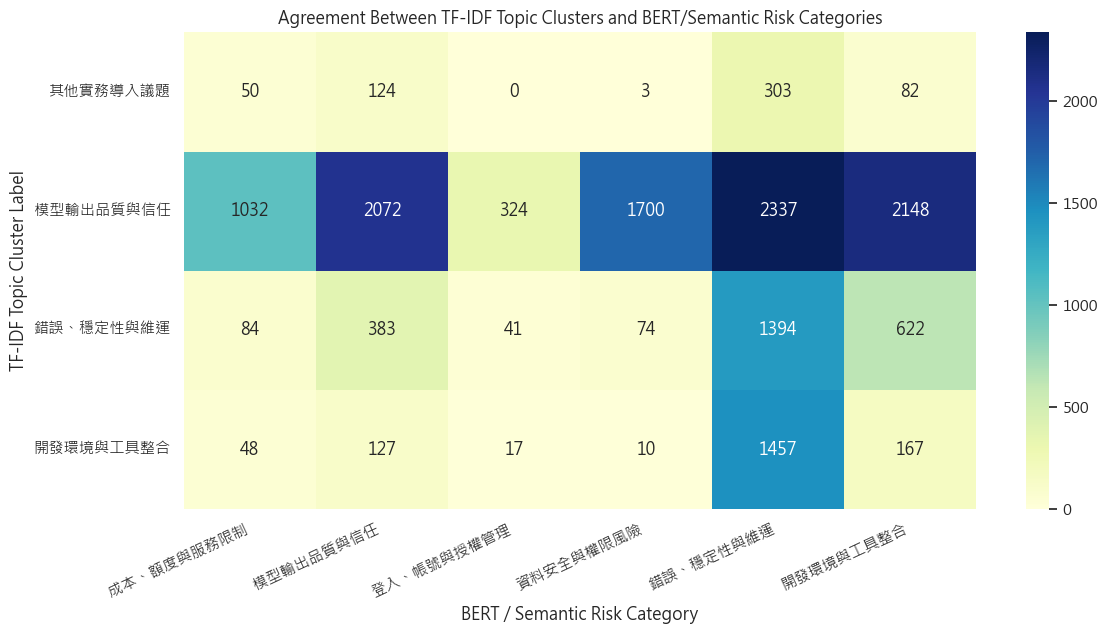

In [ ]:
# 用交叉表與熱圖比較主題分群和語意風險分類的一致性。
agreement_matrix = pd.crosstab(df["topic_label"], df["semantic_risk_category"])
display(agreement_matrix)

plt.figure(figsize=(12, 6.5))
sns.heatmap(agreement_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Agreement Between TF-IDF Topic Clusters and BERT/Semantic Risk Categories")
plt.xlabel("BERT / Semantic Risk Category")
plt.ylabel("TF-IDF Topic Cluster Label")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(Markdown(
    "此熱圖檢查傳統主題分群與 BERT 語意分類是否互相支持。"
    "若某一列集中在單一語意風險，表示該 TF-IDF 主題具有明確管理意義；"
    "若分散在多個語意風險，代表該主題可能混合多種問題，需要回看原文或重新細分。"
))


,risk_category,top_n,tfidf_bert_overlap,svd_bert_overlap,tfidf_bert_overlap_ratio,svd_bert_overlap_ratio
0,資料安全與權限風險,10,0,0,0.0,0.0
1,模型輸出品質與信任,10,0,0,0.0,0.0
2,錯誤、穩定性與維運,10,0,0,0.0,0.0
4,成本、額度與服務限制,10,0,0,0.0,0.0
5,開發環境與工具整合,10,1,1,0.1,0.1
3,登入、帳號與授權管理,10,2,0,0.2,0.0


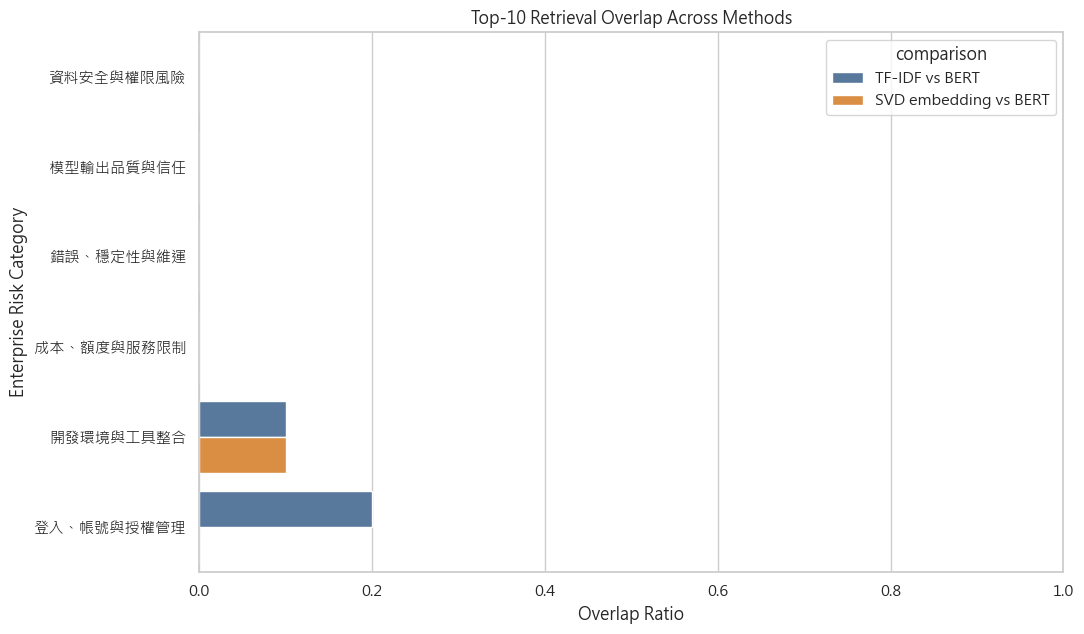

In [ ]:
# 比較不同文字表示法在同一風險查詢下的 Top-N 重疊程度。
def top_indices(score_matrix, profile_idx, n=10):
    n = min(n, score_matrix.shape[0])
    return np.argsort(score_matrix[:, profile_idx])[::-1][:n]


overlap_rows = []
top_n = min(10, len(df))
for idx, profile in enumerate(profile_names):
    tfidf_top = set(top_indices(tfidf_risk_scores, idx, top_n))
    svd_top = set(top_indices(svd_risk_scores, idx, top_n))
    bert_top = set(top_indices(semantic_scores, idx, top_n))
    overlap_rows.append(
        {
            "risk_category": profile,
            "top_n": top_n,
            "tfidf_bert_overlap": len(tfidf_top & bert_top),
            "svd_bert_overlap": len(svd_top & bert_top),
            "tfidf_bert_overlap_ratio": len(tfidf_top & bert_top) / top_n,
            "svd_bert_overlap_ratio": len(svd_top & bert_top) / top_n,
        }
    )

overlap_df = pd.DataFrame(overlap_rows).sort_values("tfidf_bert_overlap_ratio")
display(overlap_df)

overlap_plot = overlap_df.melt(
    id_vars=["risk_category"],
    value_vars=["tfidf_bert_overlap_ratio", "svd_bert_overlap_ratio"],
    var_name="comparison",
    value_name="overlap_ratio",
)
overlap_plot["comparison"] = overlap_plot["comparison"].map(
    {
        "tfidf_bert_overlap_ratio": "TF-IDF vs BERT",
        "svd_bert_overlap_ratio": "SVD embedding vs BERT",
    }
)

plt.figure(figsize=(11, 6.5))
sns.barplot(data=overlap_plot, x="overlap_ratio", y="risk_category", hue="comparison", palette=["#4C78A8", "#F28E2B"])
plt.title("Top-10 Retrieval Overlap Across Methods")
plt.xlabel("Overlap Ratio")
plt.ylabel("Enterprise Risk Category")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

display(Markdown(
    "此圖衡量不同方法在同一風險查詢下找到的前 10 筆文件是否相同。"
    "重疊率低表示 BERT 找到與關鍵詞不同但語意接近的文件；"
    "重疊率高表示該風險類別的字面詞彙已足夠明確。"
))


In [ ]:
# 整理各風險類別的代表文件，作為模型判斷的原文證據。
def make_excerpt(text, max_len=180):
    value = re.sub(r"\s+", " ", str(text)).strip()
    return value[:max_len] + ("..." if len(value) > max_len else "")


evidence_rows = []
score_matrices = {
    "TF-IDF": tfidf_risk_scores,
    "TF-IDF/SVD embedding": svd_risk_scores,
    "Sentence-BERT embedding": semantic_scores,
}
for profile_idx, profile in enumerate(profile_names):
    for method_name, scores in score_matrices.items():
        top_doc_idx = int(np.argsort(scores[:, profile_idx])[::-1][0])
        row = df.iloc[top_doc_idx]
        evidence_rows.append(
            {
                "risk_category": profile,
                "method": method_name,
                "score": round(float(scores[top_doc_idx, profile_idx]), 4),
                "repo": row["repo"],
                "source_type": row["source_type"],
                "title": make_excerpt(row["title"], 80),
                "excerpt": make_excerpt(row["text"], 180),
                "url": row["url"],
            }
        )

evidence_df = pd.DataFrame(evidence_rows)
display(evidence_df)

display(Markdown(
    "此表提供模型判斷的原文證據。報告解釋不只依賴分數，還需回到 title、excerpt 與 repo 來源，"
    "確認模型找到的文件確實能支持該風險分類。"
))


,risk_category,method,score,repo,source_type,title,excerpt,url
0,資料安全與權限風險,TF-IDF,0.4332,Hacker News / prompt injection,comment,I’m joining OpenAI,I’m joining OpenAI Are there any with a credib...,https://news.ycombinator.com/item?id=47029859
1,資料安全與權限風險,TF-IDF/SVD embedding,0.8719,Hacker News / local LLM,comment,Garmin-health-data – Own your Garmin data anal...,Garmin-health-data – Own your Garmin data anal...,https://news.ycombinator.com/item?id=47970513
2,資料安全與權限風險,Sentence-BERT embedding,0.5117,Hacker News / prompt injection,comment,"""Disregard That"" Attacks","""Disregard That"" Attacks You don't even need t...",https://news.ycombinator.com/item?id=47534867
3,模型輸出品質與信任,TF-IDF,0.4774,microsoft/vscode-copilot-release,comment,copilot is not working,is it giving the wrong answer? no answer? an e...,https://github.com/microsoft/vscode-copilot-re...
4,模型輸出品質與信任,TF-IDF/SVD embedding,0.7211,run-llama/llama_index,issue,[Question]: How to add history and memory func...,[Question]: How to add history and memory func...,https://github.com/run-llama/llama_index/issue...
5,模型輸出品質與信任,Sentence-BERT embedding,0.4992,Hacker News / AI agent,comment,Shunning AI is the human choice,Shunning AI is the human choice I don't use mu...,https://news.ycombinator.com/item?id=48225646
6,錯誤、穩定性與維運,TF-IDF,0.7123,microsoft/vscode-copilot-release,comment,Server error 503,我也出现了相同的问题。 版本: 1.100.0-insider (Universal) 提交...,https://github.com/microsoft/vscode-copilot-re...
7,錯誤、穩定性與維運,TF-IDF/SVD embedding,0.9447,microsoft/vscode-copilot-release,comment,Server error 503,我也出现了相同的问题。 版本: 1.100.0-insider (Universal) 提交...,https://github.com/microsoft/vscode-copilot-re...
8,錯誤、穩定性與維運,Sentence-BERT embedding,0.5126,microsoft/vscode-copilot-release,issue,Persistent Error – Request Timeout (Request ID...,Persistent Error – Request Timeout (Request ID...,https://github.com/microsoft/vscode-copilot-re...
9,登入、帳號與授權管理,TF-IDF,0.5191,microsoft/vscode-copilot-release,comment,Repeats roughly the same response forever.,initial user account is deleted so closing,https://github.com/microsoft/vscode-copilot-re...


### 情緒分類模型比較

這段比較 baseline、BoW、TF-IDF 與 BERT embedding 在情緒弱標籤分類上的表現。


,documents
sentiment_label,
positive,8610
negative,5160
neutral,829


,model,accuracy,macro_f1,weighted_f1
0,TF-IDF + LinearSVC,0.742009,0.652105,0.748225
1,TF-IDF + LogisticRegression,0.712329,0.622389,0.729981
2,BERT embedding + LogisticRegression,0.637443,0.546371,0.667161
3,Binary BoW + ComplementNB,0.550685,0.418857,0.553876
4,Dummy baseline,0.589726,0.247307,0.437530


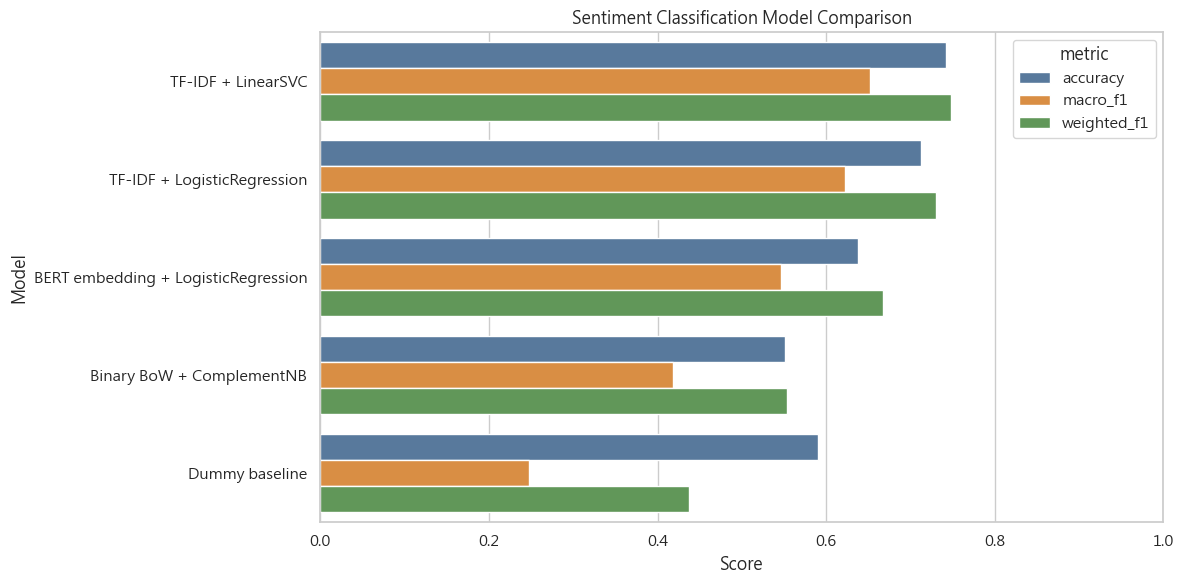

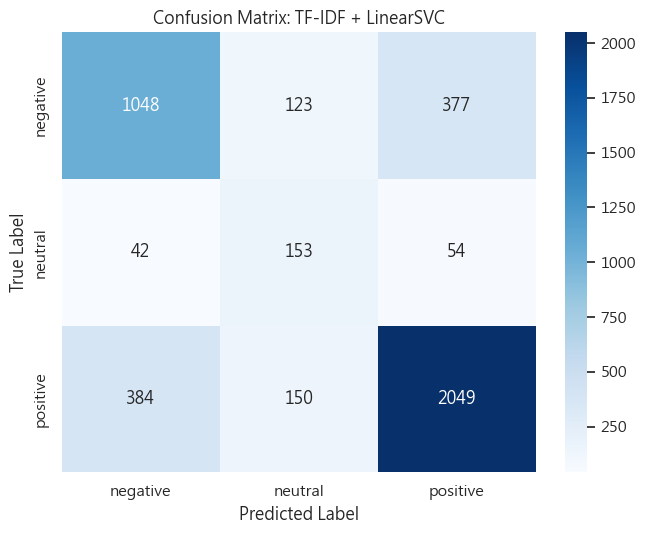

,sentiment_class,important_terms
0,negative,"error, bug, bad, failed, wrong, problem, serve..."
1,neutral,"langchain_openai, properly, type bug, built, a..."
2,positive,"free, love, best, like, value, stable, pretty,..."


In [ ]:
# 建立情緒分類模型比較，檢查不同特徵表示的分類效果。
label_counts = df["sentiment_label"].value_counts()
display(label_counts.rename("documents").to_frame())

classification_results = []
trained_models = {}
best_model_name = None
best_pred = None
best_labels = None

if len(df) >= 40 and label_counts.min() >= 5 and df["sentiment_label"].nunique() >= 2:
    y = df["sentiment_label"].values
    idx = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        idx,
        test_size=0.3,
        random_state=42,
        stratify=y,
    )
    y_train = y[train_idx]
    y_test = y[test_idx]

    model_specs = [
        ("Dummy baseline", None, DummyClassifier(strategy="most_frequent")),
        ("Binary BoW + ComplementNB", binary_bow, ComplementNB()),
        ("TF-IDF + LogisticRegression", tfidf_matrix, LogisticRegression(max_iter=1000, class_weight="balanced")),
        ("TF-IDF + LinearSVC", tfidf_matrix, LinearSVC(class_weight="balanced", random_state=42)),
        ("BERT embedding + LogisticRegression", bert_embeddings, LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]

    for name, features, clf in model_specs:
        if features is None:
            clf.fit(np.zeros((len(train_idx), 1)), y_train)
            pred = clf.predict(np.zeros((len(test_idx), 1)))
        else:
            clf.fit(features[train_idx], y_train)
            pred = clf.predict(features[test_idx])
        classification_results.append(
            {
                "model": name,
                "accuracy": accuracy_score(y_test, pred),
                "macro_f1": f1_score(y_test, pred, average="macro"),
                "weighted_f1": f1_score(y_test, pred, average="weighted"),
            }
        )
        trained_models[name] = clf

    classification_results_df = (
        pd.DataFrame(classification_results)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )
    display(classification_results_df)

    metric_plot = classification_results_df.melt(
        id_vars="model",
        value_vars=["accuracy", "macro_f1", "weighted_f1"],
        var_name="metric",
        value_name="score",
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(data=metric_plot, x="score", y="model", hue="metric", palette=["#4C78A8", "#F28E2B", "#59A14F"])
    plt.title("Sentiment Classification Model Comparison")
    plt.xlabel("Score")
    plt.ylabel("Model")
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

    best_model_name = classification_results_df.iloc[0]["model"]
    best_model = trained_models[best_model_name]
    if best_model_name == "Dummy baseline":
        best_pred = best_model.predict(np.zeros((len(test_idx), 1)))
    elif best_model_name == "BERT embedding + LogisticRegression":
        best_pred = best_model.predict(bert_embeddings[test_idx])
    elif best_model_name == "Binary BoW + ComplementNB":
        best_pred = best_model.predict(binary_bow[test_idx])
    else:
        best_pred = best_model.predict(tfidf_matrix[test_idx])

    best_labels = sorted(label_counts.index.tolist())
    cm = confusion_matrix(y_test, best_pred, labels=best_labels)
    plt.figure(figsize=(6.8, 5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=best_labels, yticklabels=best_labels)
    plt.title(f"Confusion Matrix: {best_model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    display(Markdown(
        f"情緒分類最佳模型為 **{best_model_name}**。"
        "此比較能說明不同文字表示是否真的帶來可測量的分類能力；若模型只略高於 Dummy baseline，"
        "代表自動情緒標籤或資料本身仍需增加人工標註與資料量。"
    ))

    if "TF-IDF + LinearSVC" in trained_models:
        svc = trained_models["TF-IDF + LinearSVC"]
        coef_rows = []
        classes = svc.classes_
        coef_matrix = svc.coef_
        for class_idx, class_name in enumerate(classes):
            weights = coef_matrix[class_idx]
            top_idx = weights.argsort()[::-1][:8]
            coef_rows.append(
                {
                    "sentiment_class": class_name,
                    "important_terms": ", ".join(tfidf_terms[top_idx]),
                }
            )
        coefficient_explanation = pd.DataFrame(coef_rows)
        display(coefficient_explanation)
        display(Markdown(
            "LinearSVC 的重要詞表提供模型解釋：它指出哪些詞彙最容易推動模型判斷為 positive、neutral 或 negative。"
            "這比單看準確率更適合放入資料探勘報告。"
        ))
else:
    classification_results_df = pd.DataFrame(columns=["model", "accuracy", "macro_f1", "weighted_f1"])
    display(Markdown(
        "情緒分類模型未執行，原因是目前各情緒類別資料量不足以進行穩定的 train/test split。"
        "此時應優先擴充社群留言資料或加入人工標註。"
    ))


In [ ]:
# 整理最佳分類模型的分類報告，輔助解釋模型表現。
# 情緒分類 precision / recall / F1 by class 與評估解釋

if "best_pred" in globals() and best_pred is not None and "y_test" in globals():
    report_dict = classification_report(y_test, best_pred, labels=best_labels, output_dict=True, zero_division=0)
    classification_report_df = (
        pd.DataFrame(report_dict)
        .T
        .reset_index(names="label")
    )
    display(classification_report_df)
    display(Markdown(
        "分類報告補充 accuracy 以外的 precision、recall 與 F1。"
        "在情緒資料不均衡時，macro F1 比 accuracy 更能反映少數類別是否被模型學到；"
        "weighted F1 則反映整體樣本量加權後的表現。由於標籤來自 VADER 弱標註，此結果應解讀為文字表示法可學習訊號檢查，"
        "而不是最終人工情緒標註品質。"
    ))
else:
    classification_report_df = pd.DataFrame(columns=["label", "precision", "recall", "f1-score", "support"])
    display(Markdown(
        "本次未產生 classification report，原因是情緒分類模型未執行或測試資料不足。"
        "後續若擴充資料或加入人工標註，可重新產出 precision、recall 與 F1 by class。"
    ))

,label,precision,recall,f1-score,support
0,negative,0.710991,0.677003,0.693580,1548.000000
1,neutral,0.359155,0.614458,0.453333,249.000000
2,positive,0.826210,0.793264,0.809402,2583.000000
3,accuracy,0.742009,0.742009,0.742009,0.742009
4,macro avg,0.632118,0.694908,0.652105,4380.000000
5,weighted avg,0.758937,0.742009,0.748225,4380.000000


## 視覺化的分析結果

這段產出資料量、趨勢、情緒、主題、風險與社會網絡的主要圖表與表格結果。


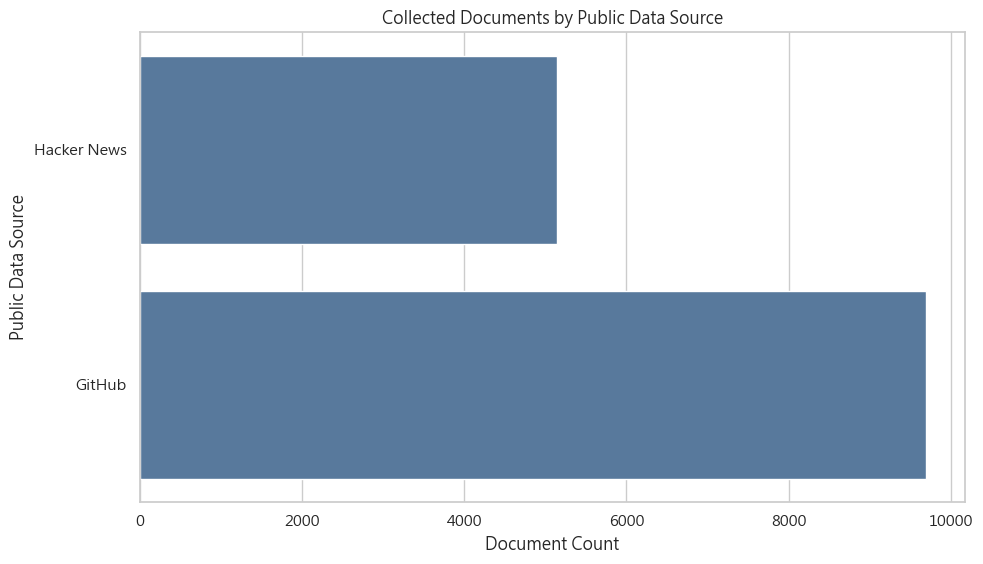

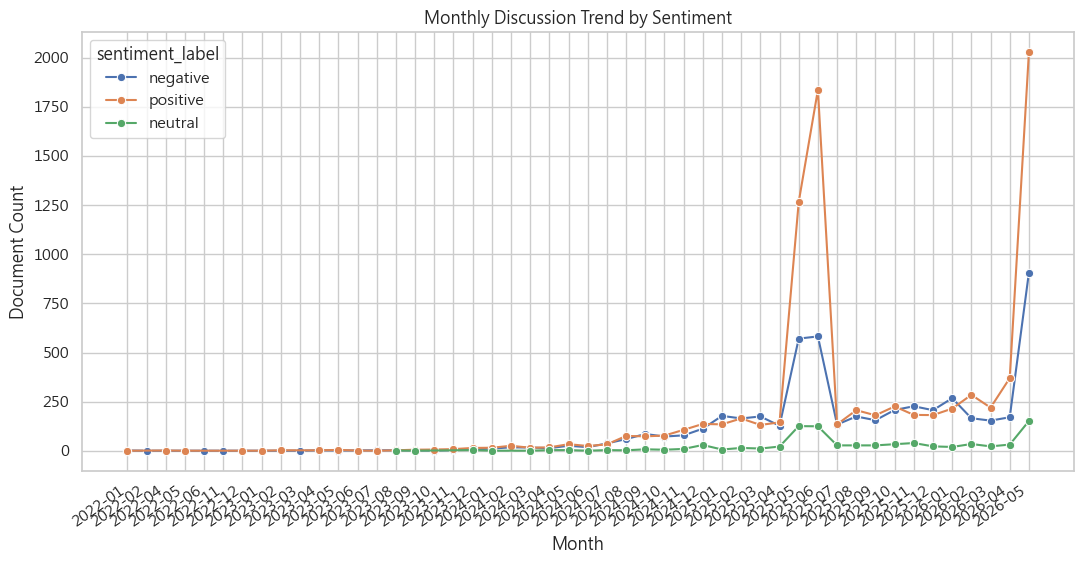

In [ ]:
# 繪製資料來源分布與時間趨勢，觀察資料量與情緒變化。
plt.figure(figsize=(10, 5.8))
source_total_plot = repo_summary["total"].sort_values(ascending=True).reset_index()
sns.barplot(data=source_total_plot, x="total", y="source_platform", color="#4C78A8")
plt.title("Collected Documents by Public Data Source")
plt.xlabel("Document Count")
plt.ylabel("Public Data Source")
plt.tight_layout()
plt.show()

display(Markdown(
    "資料量分布圖用於確認 GitHub 與 Hacker News 對整體分析的貢獻。"
    "GitHub 較適合解釋技術問題，Hacker News 較適合解釋社群態度；兩者合併可讓資料探勘方法更完整。"
))

monthly = (
    df.dropna(subset=["created_at"])
    .assign(month=lambda x: x["created_at"].dt.to_period("M").astype(str))
    .groupby(["month", "sentiment_label"])
    .size()
    .reset_index(name="count")
)

if monthly["month"].nunique() >= 3 and monthly["count"].sum() >= 30:
    plt.figure(figsize=(11, 5.8))
    sns.lineplot(data=monthly, x="month", y="count", hue="sentiment_label", marker="o")
    plt.title("Monthly Discussion Trend by Sentiment")
    plt.xlabel("Month")
    plt.ylabel("Document Count")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown(
        "時間序列圖未繪製，原因是目前資料月份數或文件量不足以支持穩定趨勢解釋。"
        "本研究改以主題分布、語意風險與負面比例作為主要判讀依據。"
    ))


,user,weighted_degree,pagerank,betweenness
0,vs-code-engineering[bot],1051,0.265368,0.000000
1,rebornix,43,0.013909,0.000018
2,Yoyokrazy,75,0.013738,0.000010
3,amunger,36,0.005808,0.000000
4,aiday-mar,22,0.004264,0.000000
5,eleanorjboyd,10,0.003032,0.000000
6,justschen,7,0.002614,0.000000
7,bamurtaugh,9,0.002278,0.000000
8,roblourens,17,0.002070,0.000000
9,TylerLeonhardt,11,0.002045,0.000000


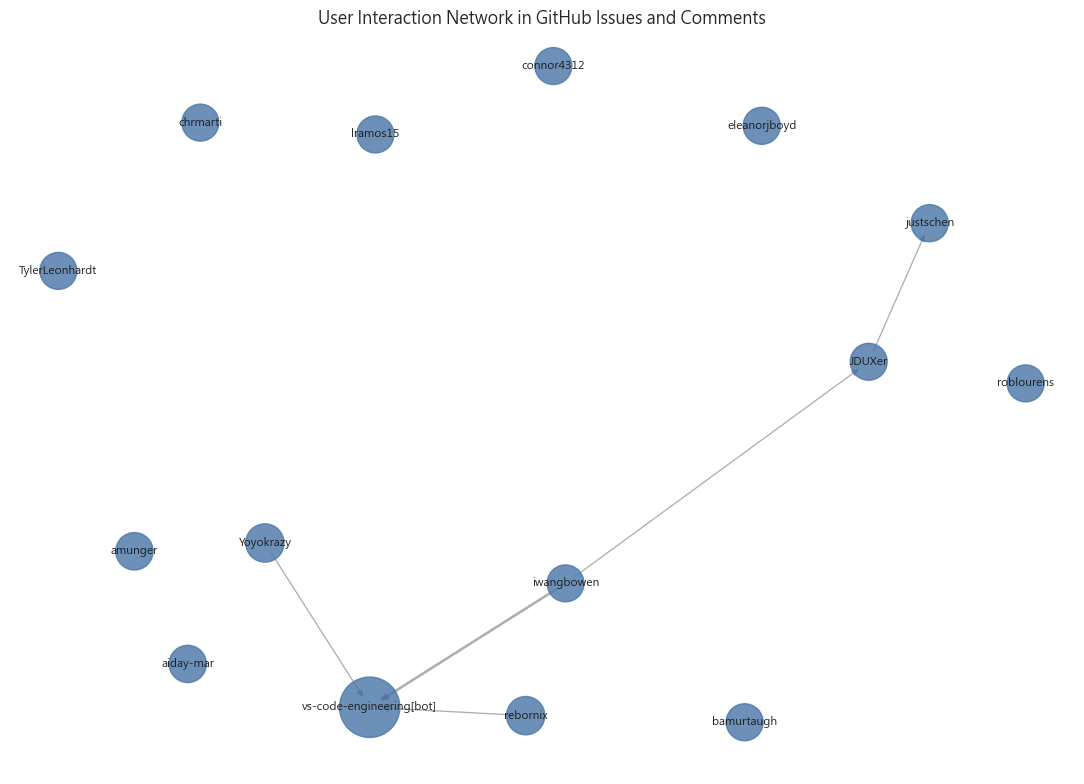

In [ ]:
# 建立使用者互動網絡，計算核心參與者與互動結構。
interaction_base = df[df["source_type"].eq("comment")].copy()
id_to_user = dict(zip(interaction_base.get("document_id", pd.Series(dtype=str)).astype(str), interaction_base["user"].astype(str)))
interaction_base["parent_author"] = interaction_base.get("parent_id", pd.Series(index=interaction_base.index, dtype=str)).astype(str).map(id_to_user)
interaction_base["interaction_source"] = np.where(
    interaction_base["source_platform"].eq("GitHub"),
    interaction_base["issue_author"].astype(str),
    interaction_base["parent_author"].fillna(""),
)

interaction_df = (
    interaction_base
    .loc[:, ["repo", "issue_number", "interaction_source", "user"]]
    .dropna()
    .rename(columns={"interaction_source": "issue_author"})
)
interaction_df = interaction_df[interaction_df["issue_author"].str.strip().ne("")]
interaction_df = interaction_df[interaction_df["issue_author"].ne(interaction_df["user"])]

user_graph = nx.DiGraph()
for row in interaction_df.itertuples(index=False):
    source = str(row.issue_author)
    target = str(row.user)
    if not source or not target:
        continue
    if user_graph.has_edge(source, target):
        user_graph[source][target]["weight"] += 1
    else:
        user_graph.add_edge(source, target, weight=1, repo=row.repo)

if user_graph.number_of_nodes() > 1:
    pagerank = nx.pagerank(user_graph, weight="weight")
    degree_weight = dict(user_graph.degree(weight="weight"))
    betweenness = nx.betweenness_centrality(user_graph)
    centrality_df = (
        pd.DataFrame(
            {
                "user": list(user_graph.nodes()),
                "weighted_degree": [degree_weight.get(node, 0) for node in user_graph.nodes()],
                "pagerank": [pagerank.get(node, 0) for node in user_graph.nodes()],
                "betweenness": [betweenness.get(node, 0) for node in user_graph.nodes()],
            }
        )
        .sort_values(["pagerank", "weighted_degree"], ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
    display(centrality_df)
    display(Markdown(
        "使用者互動中心性表用於辨識討論中的核心參與者。"
        "PageRank 較高者通常代表其 issue 或留言位置較容易被其他討論連結到；"
        "此結果適合用於觀察社群互動結構，不代表該帳號在組織中的正式影響力。"
    ))

    top_nodes = centrality_df["user"].head(30).tolist()
    subgraph = user_graph.subgraph(top_nodes).copy()
    plt.figure(figsize=(11, 8))
    pos = nx.spring_layout(subgraph, seed=42, k=0.8)
    node_sizes = [700 + 4500 * pagerank.get(node, 0) for node in subgraph.nodes()]
    edge_widths = [0.5 + subgraph[u][v].get("weight", 1) * 0.45 for u, v in subgraph.edges()]
    nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, node_color="#4C78A8", alpha=0.82)
    nx.draw_networkx_edges(subgraph, pos, width=edge_widths, alpha=0.35, arrows=True, arrowstyle="-|>")
    nx.draw_networkx_labels(subgraph, pos, font_size=8)
    plt.title("User Interaction Network in GitHub Issues and Comments")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    centrality_df = pd.DataFrame(columns=["user", "weighted_degree", "pagerank", "betweenness"])
    display(Markdown("使用者互動資料不足，未建立互動網絡。"))


,keyword,weighted_degree
0,issue,130246
1,version,122209
2,code,121861
3,bug,111088
4,info,109152
5,system,108735
6,gpu,98660
7,type,97590
8,extension,94071
9,value,93367


,keyword_a,keyword_b,co_occurrence
0,issue,version,4248
1,code,issue,3568
2,code,version,3539
3,bug,issue,3489
4,bug,version,3302
5,info,issue,3210
6,bug,code,3044
7,bug,info,3035
8,gpu,version,2902
9,gpu,issue,2899


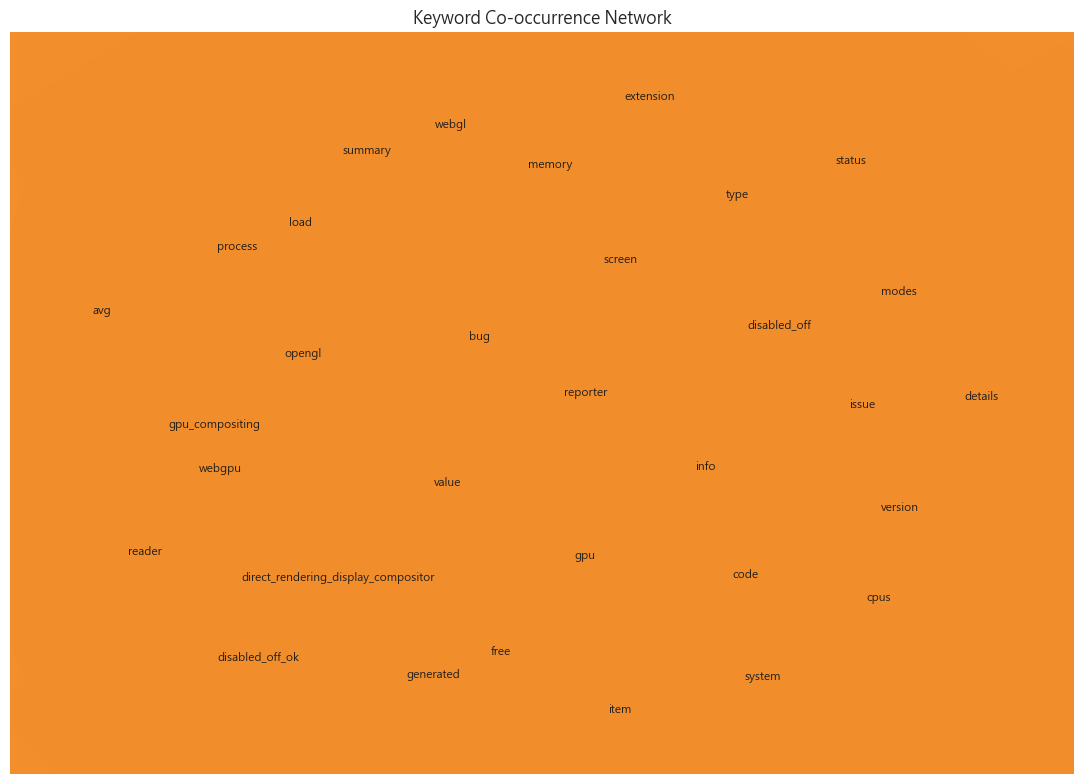

In [ ]:
# 建立關鍵詞共現網絡，觀察技術議題之間的連結。
binary_matrix = (count_matrix > 0).astype(int)
cooc_matrix = (binary_matrix.T @ binary_matrix).toarray()
np.fill_diagonal(cooc_matrix, 0)

keyword_graph = nx.Graph()
for i, j in zip(*np.triu_indices_from(cooc_matrix, k=1)):
    weight = int(cooc_matrix[i, j])
    if weight >= 2:
        keyword_graph.add_edge(terms[i], terms[j], weight=weight)

if keyword_graph.number_of_edges() > 0:
    keyword_degree = dict(keyword_graph.degree(weight="weight"))
    key_nodes = sorted(keyword_degree, key=keyword_degree.get, reverse=True)[:32]
    keyword_subgraph = keyword_graph.subgraph(key_nodes).copy()

    keyword_centrality = (
        pd.DataFrame(
            {
                "keyword": list(keyword_graph.nodes()),
                "weighted_degree": [keyword_degree.get(node, 0) for node in keyword_graph.nodes()],
            }
        )
        .sort_values("weighted_degree", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
    display(keyword_centrality)

    keyword_edges = (
        pd.DataFrame(
            [
                {"keyword_a": u, "keyword_b": v, "co_occurrence": attr["weight"]}
                for u, v, attr in keyword_graph.edges(data=True)
            ]
        )
        .sort_values("co_occurrence", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
    display(keyword_edges)

    plt.figure(figsize=(11, 8))
    pos = nx.spring_layout(keyword_subgraph, seed=42, k=0.65)
    node_sizes = [250 + keyword_degree.get(node, 1) * 38 for node in keyword_subgraph.nodes()]
    edge_widths = [0.4 + keyword_subgraph[u][v].get("weight", 1) * 0.16 for u, v in keyword_subgraph.edges()]
    nx.draw_networkx_nodes(keyword_subgraph, pos, node_size=node_sizes, node_color="#F28E2B", alpha=0.85)
    nx.draw_networkx_edges(keyword_subgraph, pos, width=edge_widths, alpha=0.28)
    nx.draw_networkx_labels(keyword_subgraph, pos, font_size=8)
    plt.title("Keyword Co-occurrence Network")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    display(Markdown(
        "議題共現網絡與邊列表用於說明哪些技術詞經常一起出現。"
        "若 `token`、`security`、`access` 等詞形成連結，可解釋為權限與資料安全議題；"
        "若 `error`、`failed`、`timeout` 等詞連結，則偏向維運穩定性問題。"
    ))
else:
    keyword_centrality = pd.DataFrame(columns=["keyword", "weighted_degree"])
    display(Markdown("關鍵詞共現資料不足，未建立議題共現網絡。"))


topic_label,其他實務導入議題,模型輸出品質與信任,錯誤、穩定性與維運,開發環境與工具整合
repo,,,,
Hacker News / AI agent,0,963,0,0
Hacker News / AI coding assistant,0,41,0,0
Hacker News / ChatGPT coding,0,45,0,0
Hacker News / GitHub Copilot,0,48,0,0
Hacker News / Ollama,0,100,0,0
Hacker News / OpenAI API,0,47,0,0
Hacker News / RAG,0,973,0,0
Hacker News / code generation,0,47,0,0
Hacker News / data privacy AI coding,0,112,0,0


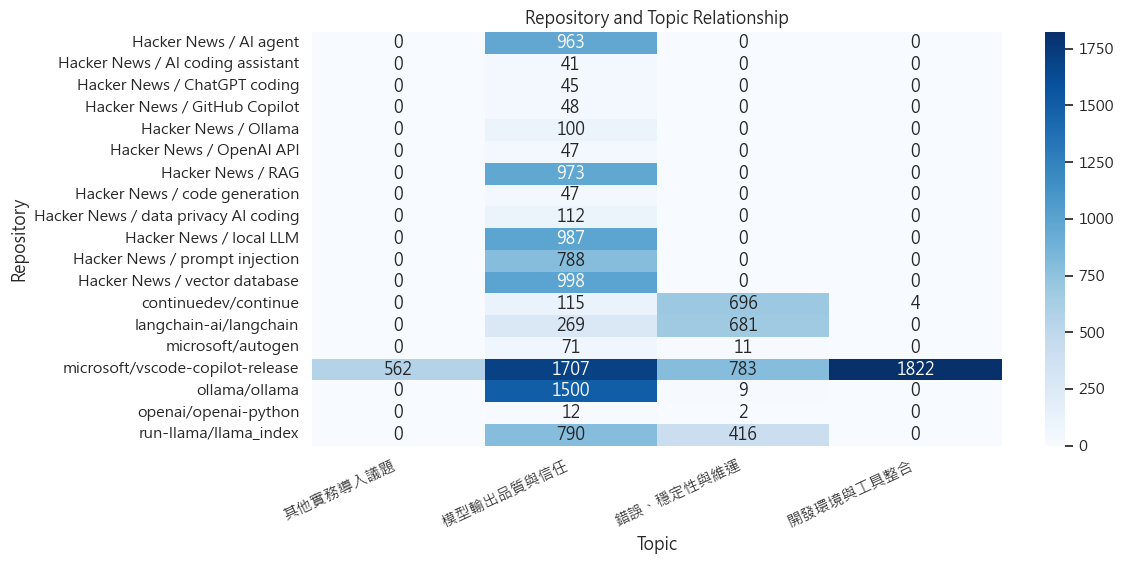

In [ ]:
# 建立 repo 與主題交叉表，分析不同專案的問題類型分布。
repo_topic = pd.crosstab(df["repo"], df["topic_label"])
display(repo_topic)

plt.figure(figsize=(12, 5.8))
sns.heatmap(repo_topic, annot=True, fmt="d", cmap="Blues")
plt.title("Repository and Topic Relationship")
plt.xlabel("Topic")
plt.ylabel("Repository")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

display(Markdown(
    "repo 與主題的交叉表比二分網絡更適合解釋此研究問題，"
    "因為它直接呈現每個 repo 的問題類型分布，可用於比較 Copilot、OpenAI SDK 與 LangChain 社群的痛點差異。"
))


In [ ]:
# 整理負面主題與企業導入建議，形成管理面結論。
negative_topic = (
    df[df["sentiment_label"].eq("negative")]
    .groupby("topic_label")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="negative_documents")
)

recommendations = pd.DataFrame(
    [
        {
            "企業導入議題": "資料安全與權限控管",
            "社群觀察重點": "token、key、privacy、security 等詞若集中出現，代表工具導入必須先定義敏感資料與程式碼上傳邊界。",
            "管理建議": "建立 AI 工具使用規範、敏感資料清單、權限分級與稽核紀錄。",
        },
        {
            "企業導入議題": "模型輸出品質與信任",
            "社群觀察重點": "incorrect、wrong、hallucination、suggestion 等詞反映輸出可信度與驗證成本。",
            "管理建議": "保留人工 code review、測試案例與關鍵系統變更審核流程。",
        },
        {
            "企業導入議題": "開發環境與維運整合",
            "社群觀察重點": "extension、version、workspace、error、crash 等詞常對應導入初期阻礙。",
            "管理建議": "先以小組試點驗證 IDE、內部網路、套件版本與權限政策相容性。",
        },
        {
            "企業導入議題": "成本與服務限制",
            "社群觀察重點": "quota、rate limit、billing、plan 等詞與服務穩定性及預算控管相關。",
            "管理建議": "建立使用量監控、預算上限、帳號管理與替代流程。",
        },
    ]
)

display(Markdown("### 負面討論較集中的主題"))
display(negative_topic)
display(Markdown("### 企業導入 AI 開發工具的管理建議"))
display(recommendations)


,topic_label,negative_documents
0,模型輸出品質與信任,2951
1,錯誤、穩定性與維運,1751
2,開發環境與工具整合,456
3,其他實務導入議題,2


,企業導入議題,社群觀察重點,管理建議
0,資料安全與權限控管,token、key、privacy、security 等詞若集中出現，代表工具導入必須先定義...,建立 AI 工具使用規範、敏感資料清單、權限分級與稽核紀錄。
1,模型輸出品質與信任,incorrect、wrong、hallucination、suggestion 等詞反映輸...,保留人工 code review、測試案例與關鍵系統變更審核流程。
2,開發環境與維運整合,extension、version、workspace、error、crash 等詞常對應導...,先以小組試點驗證 IDE、內部網路、套件版本與權限政策相容性。
3,成本與服務限制,quota、rate limit、billing、plan 等詞與服務穩定性及預算控管相關。,建立使用量監控、預算上限、帳號管理與替代流程。
